In [ ]:
"""
Pipeline de limpeza e modelagem para triagem de cardiopatia infantil (UCMF).

Compara duas abordagens via validação cruzada:
  - Cenário A: modelo COM achados de exame clínico (sopro, pulsos, B2, PPA)
  - Cenário B: modelo SEM esses achados, simulando uma triagem "cega"
                (sem depender de auscultação especializada)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import warnings

warnings.filterwarnings('ignore')


# ==========================================
# 1. FUNÇÕES DE LIMPEZA E ENGENHARIA
# ==========================================
def normalizar_alta_cardinalidade(serie, top_n=15, rotulo_outro='OUTRO',
                                   rotulo_nulo='NAO_INFORMADO'):
    """Reduz a cardinalidade de uma coluna categórica.

    Preenche nulos ANTES de qualquer conversão de texto (evita o clássico bug
    de NaN virar a string literal "nan"), padroniza maiúsculas/espaços e
    agrupa categorias pouco frequentes em 'OUTRO'. Isso evita que centenas de
    variantes de digitação (ex: 'Camed' / 'CAMED' / 'camed') virem centenas de
    colunas dummy ruidosas no one-hot encoding — o que, além de caro
    computacionalmente, infla artificialmente a importância de variáveis no
    Random Forest (a importância de Gini tem viés a favor de variáveis de
    alta cardinalidade).
    """
    serie = serie.fillna(rotulo_nulo).str.strip().str.upper()
    top_categorias = serie.value_counts().nlargest(top_n).index
    return serie.where(serie.isin(top_categorias), rotulo_outro)


def carregar_e_limpar_dados(filepath):
    df = pd.read_csv(filepath)

    # Importante: NÃO usamos mais .astype(str) em colunas inteiras. Fazer isso
    # pode transformar valores ausentes reais na string literal "nan", que
    # depois escapa de qualquer tratamento de nulo (ex: SimpleImputer não
    # reconhece "nan" como nulo, e .str[0] em "nan" geraria "N" para SEXO).
    # O acessor .str já propaga NaN corretamente sem precisar dessa conversão.
    colunas_texto = df.select_dtypes(include=['object']).columns
    for col in colunas_texto:
        df[col] = df[col].str.strip()

    df['NORMAL X ANORMAL'] = df['NORMAL X ANORMAL'].str.title().replace('Normais', 'Normal')
    df['SEXO'] = df['SEXO'].str.upper().str[0].replace('I', np.nan)
    df['SOPRO'] = df['SOPRO'].replace({'sistólico': 'Sistólico', 'contínuo': 'Contínuo'})
    df['PULSOS'] = df['PULSOS'].replace({'NORMAIS': 'Normais', 'AMPLOS': 'Amplos'})
    df['PPA'] = df['PPA'].replace(['#VALUE!', 'Não Calculado'], np.nan)

    # Convenio tem ~370 categorias na base original, muitas delas a mesma
    # coisa escrita de formas diferentes. Normalizamos e agrupamos as raras
    # em 'OUTRO' antes de qualquer encoding.
    df['Convenio'] = normalizar_alta_cardinalidade(df['Convenio'], top_n=15)

    return df


def tratar_datas_e_idade(df):
    def parse_data_com_correcao_seculo(serie):
        datas = pd.to_datetime(serie, format='%d/%m/%y', errors='coerce')
        # Ano de 2 dígitos é ambíguo (ex: "27" pode virar 2027 em vez de 1927
        # dependendo da convenção do sistema). Como a base é histórica,
        # qualquer data de nascimento "no futuro" é erro de século, não dado
        # inválido — corrigimos em vez de simplesmente descartar a linha.
        futuras = datas > pd.Timestamp.now()
        datas.loc[futuras] = datas.loc[futuras] - pd.DateOffset(years=100)
        return datas

    dn = parse_data_com_correcao_seculo(df['DN'])
    atend = parse_data_com_correcao_seculo(df['Atendimento'])

    linhas_invalidas = df['IDADE'].isna() & (dn.isna() | atend.isna())
    df = df[~linhas_invalidas].copy()
    # Reaproveita as séries já calculadas em vez de rodar pd.to_datetime de novo
    dn = dn[~linhas_invalidas]
    atend = atend[~linhas_invalidas]

    idade_calc = (atend - dn).dt.days / 365.25
    df['IDADE'] = df['IDADE'].fillna(idade_calc).round(2)

    return df.drop(columns=['Atendimento', 'DN', 'ID'], errors='ignore')


def aplicar_limites_clinicos(df):
    df.loc[(df['IDADE'] < 0) | (df['IDADE'] > 19), 'IDADE'] = np.nan
    df.loc[df['Peso'] <= 0, 'Peso'] = np.nan
    df.loc[df['Altura'] <= 0, 'Altura'] = np.nan

    df['PA SISTOLICA'] = pd.to_numeric(df['PA SISTOLICA'], errors='coerce')
    df.loc[(df['PA SISTOLICA'] <= 0) | (df['PA SISTOLICA'] > 300), 'PA SISTOLICA'] = np.nan

    df['PA DIASTOLICA'] = pd.to_numeric(df['PA DIASTOLICA'], errors='coerce')
    df.loc[(df['PA DIASTOLICA'] <= 0) | (df['PA DIASTOLICA'] > 200), 'PA DIASTOLICA'] = np.nan

    df['FC'] = pd.to_numeric(df['FC'], errors='coerce')
    df.loc[(df['FC'] < 30) | (df['FC'] > 250), 'FC'] = np.nan

    # Recalcula o IMC a partir do Peso/Altura já limpos em vez de confiar no
    # valor original do CSV (que tinha outlier de até 848 nos dados brutos —
    # fisiologicamente impossível em qualquer faixa etária).
    altura_m = df['Altura'] / 100
    df['IMC'] = np.where(altura_m > 0, df['Peso'] / (altura_m ** 2), np.nan)
    df.loc[(df['IMC'] < 5) | (df['IMC'] > 45), 'IMC'] = np.nan

    return df


# ==========================================
# 2. FUNÇÕES DE MODELAGEM
# ==========================================
def construir_pipeline(num_cols, cat_cols, modelo, usar_scaler=True):
    steps_num = [('knn', KNNImputer(n_neighbors=5))]
    if usar_scaler:
        steps_num.append(('scaler', StandardScaler()))
    numeric_transformer = Pipeline(steps=steps_num)

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, num_cols),
            ('cat', categorical_transformer, cat_cols)
        ])
    # remainder='drop' (padrão do ColumnTransformer): qualquer coluna que não
    # esteja em num_cols/cat_cols seria descartada silenciosamente — por isso
    # validamos isso com um assert em avaliar_modelos_cv() antes de chegar aqui.

    return Pipeline(steps=[('preprocessor', preprocessor), ('classifier', modelo)])


def avaliar_modelos_cv(df, var_alvo='NORMAL X ANORMAL'):
    df_processed = df.copy()
    df_processed = df_processed.dropna(subset=[var_alvo])
    y = df_processed[var_alvo].map({'Normal': 0, 'Anormal': 1})

    nan_in_y_mask = y.isna()
    if nan_in_y_mask.any():
        print(f"Aviso: {nan_in_y_mask.sum()} linhas descartadas por valor "
              f"inesperado em '{var_alvo}'.")
        df_processed = df_processed[~nan_in_y_mask]
        y = y[~nan_in_y_mask]

    X = df_processed.drop(columns=[var_alvo])

    num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

    # Garante que nenhuma coluna está sendo descartada silenciosamente pelo
    # ColumnTransformer por causa de um dtype não mapeado em num_cols/cat_cols.
    colunas_nao_classificadas = set(X.columns) - set(num_cols) - set(cat_cols)
    assert not colunas_nao_classificadas, (
        f"Colunas com dtype não tratado seriam descartadas silenciosamente: "
        f"{colunas_nao_classificadas}"
    )

    # Peso para balancear classes no XGBoost (os outros modelos usam
    # class_weight='balanced' nativo do sklearn; GradientBoostingClassifier
    # não tem essa opção nativa).
    scale_pos_weight = (y == 0).sum() / max((y == 1).sum(), 1)

    modelos = {
        "Regressão Logística": (
            LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
            True
        ),
        "SVC": (
            SVC(kernel='rbf', random_state=42, class_weight='balanced'),
            True
        ),
        "Random Forest": (
            RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
            False
        ),
        "Gradient Boosting": (
            GradientBoostingClassifier(n_estimators=100, random_state=42),
            False
        ),
        "XGBoost": (
            XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss',
                           scale_pos_weight=scale_pos_weight),
            False
        ),
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    resultados = {}

    print(f"{'Modelo':<22} | {'ROC-AUC':<16} | {'F1-Score':<16} | {'Recall (Anormal)'}")
    print("-" * 78)

    for nome, (modelo, usar_scaler) in modelos.items():
        pipeline = construir_pipeline(num_cols, cat_cols, modelo, usar_scaler)
        scores = cross_validate(
            pipeline, X, y, cv=cv,
            scoring=['roc_auc', 'f1', 'recall'],
            n_jobs=-1
        )

        roc_auc, roc_std = scores['test_roc_auc'].mean(), scores['test_roc_auc'].std()
        f1, f1_std = scores['test_f1'].mean(), scores['test_f1'].std()
        recall = scores['test_recall'].mean()

        # IMPORTANTE: este 'pipeline' NÃO foi treinado aqui. cross_validate()
        # clona o estimador internamente para cada fold e descarta os clones
        # ao final. O fit() real acontece em extrair_importancias_rf(), que é
        # quem efetivamente precisa do modelo treinado para olhar
        # feature_importances_.
        resultados[nome] = pipeline

        print(f"{nome:<22} | {roc_auc:.4f} +/- {roc_std:.4f} | "
              f"{f1:.4f} +/- {f1_std:.4f} | {recall:.4f}")

    return resultados, X, y, num_cols, cat_cols


def extrair_importancias_rf(pipeline, X, y, num_cols, cat_cols):
    """Treina o modelo recebido (precisa ter .feature_importances_, ex:
    Random Forest, Gradient Boosting, XGBoost) e extrai os nomes corretos das
    features na ordem real produzida pelo ColumnTransformer: primeiro as
    numéricas (na ordem de num_cols), depois as dummies do one-hot."""
    pipeline.fit(X, y)
    ohe = pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['ohe']
    cat_features_out = ohe.get_feature_names_out(cat_cols).tolist()
    feature_names = num_cols + cat_features_out
    importancias = pd.Series(
        pipeline.named_steps['classifier'].feature_importances_,
        index=feature_names
    )
    return importancias.sort_values(ascending=True).tail(15)


# ==========================================
# 3. EXECUÇÃO PRINCIPAL (TESTE A/B)
# ==========================================
print("--- Carregando e Processando Dados ---")
df_base = carregar_e_limpar_dados('UCMF_raw.csv')
df_base = tratar_datas_e_idade(df_base)
df_base = aplicar_limites_clinicos(df_base)

# Achados que dependem de exame físico especializado (auscultação/palpação
# por um profissional treinado). PPA é a classificação percentilada derivada
# de PA SISTOLICA/PA DIASTOLICA + idade/sexo, então também entra como
# "rótulo de exame". Os valores brutos de PA SISTOLICA/PA DIASTOLICA/FC
# permanecem no Cenário B porque podem ser medidos em qualquer triagem
# básica, sem exame cardiológico especializado. Se quiser testar uma
# triagem sem NENHUMA medição clínica, inclua-os nesta lista também.
vars_exame = ['SOPRO', 'PULSOS', 'B2', 'PPA']
vars_exame_presentes = [col for col in vars_exame if col in df_base.columns]

print("\n" + "=" * 78)
print("CENÁRIO A: Modelo COM Variáveis de Exame Clínico")
print("=" * 78)
pipes_com_exame, X_com, y_com, num_com, cat_com = avaliar_modelos_cv(df_base)
importancias_com = extrair_importancias_rf(
    pipes_com_exame["Random Forest"], X_com, y_com, num_com, cat_com
)

print("\n" + "=" * 78)
print("CENÁRIO B: Modelo SEM Variáveis de Exame (Triagem Cega)")
print("=" * 78)
df_sem_exame = df_base.drop(columns=vars_exame_presentes)
pipes_sem_exame, X_sem, y_sem, num_sem, cat_sem = avaliar_modelos_cv(df_sem_exame)
importancias_sem = extrair_importancias_rf(
    pipes_sem_exame["Random Forest"], X_sem, y_sem, num_sem, cat_sem
)

# ==========================================
# 4. COMPARAÇÃO VISUAL DAS VARIÁVEIS
# ==========================================
print("\n--- Gerando Gráficos de Comparação ---")
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

importancias_com.plot(kind='barh', color='lightcoral', ax=axes[0])
axes[0].set_title('Top 15 Variáveis - COM Exame Clínico')
axes[0].set_xlabel('Importância (Random Forest)')

importancias_sem.plot(kind='barh', color='skyblue', ax=axes[1])
axes[1].set_title('Top 15 Variáveis - SEM Exame Clínico (Triagem Cega)')
axes[1].set_xlabel('Importância (Random Forest)')

plt.tight_layout()
plt.show()

--- Carregando e Processando Dados ---

CENÁRIO A: Modelo COM Variáveis de Exame Clínico
Modelo                 | ROC-AUC          | F1-Score         | Recall (Anormal)
------------------------------------------------------------------------------
Regressão Logística    | 0.9417 +/- 0.0053 | 0.9066 +/- 0.0061 | 0.8703 +/- 0.0125
SVC                    | 0.9378 +/- 0.0072 | 0.9078 +/- 0.0059 | 0.8698 +/- 0.0123
Random Forest          | 0.9467 +/- 0.0061 | 0.9077 +/- 0.0064 | 0.8681 +/- 0.0122
Gradient Boosting      | 0.9465 +/- 0.0053 | 0.9077 +/- 0.0063 | 0.8708 +/- 0.0125
XGBoost                | 0.9436 +/- 0.0073 | 0.9018 +/- 0.0068 | 0.8711 +/- 0.0115
[Holdout | CENÁRIO A: Modelo COM Variáveis de Exame Clínico] Random Forest: ROC-AUC=0.9605  F1=0.9256  Recall(Anormal)=0.8984

CENÁRIO B: Modelo SEM Variáveis de Exame (Triagem Cega)
Modelo                 | ROC-AUC          | F1-Score         | Recall (Anormal)
--------------------------------------------------------------------------

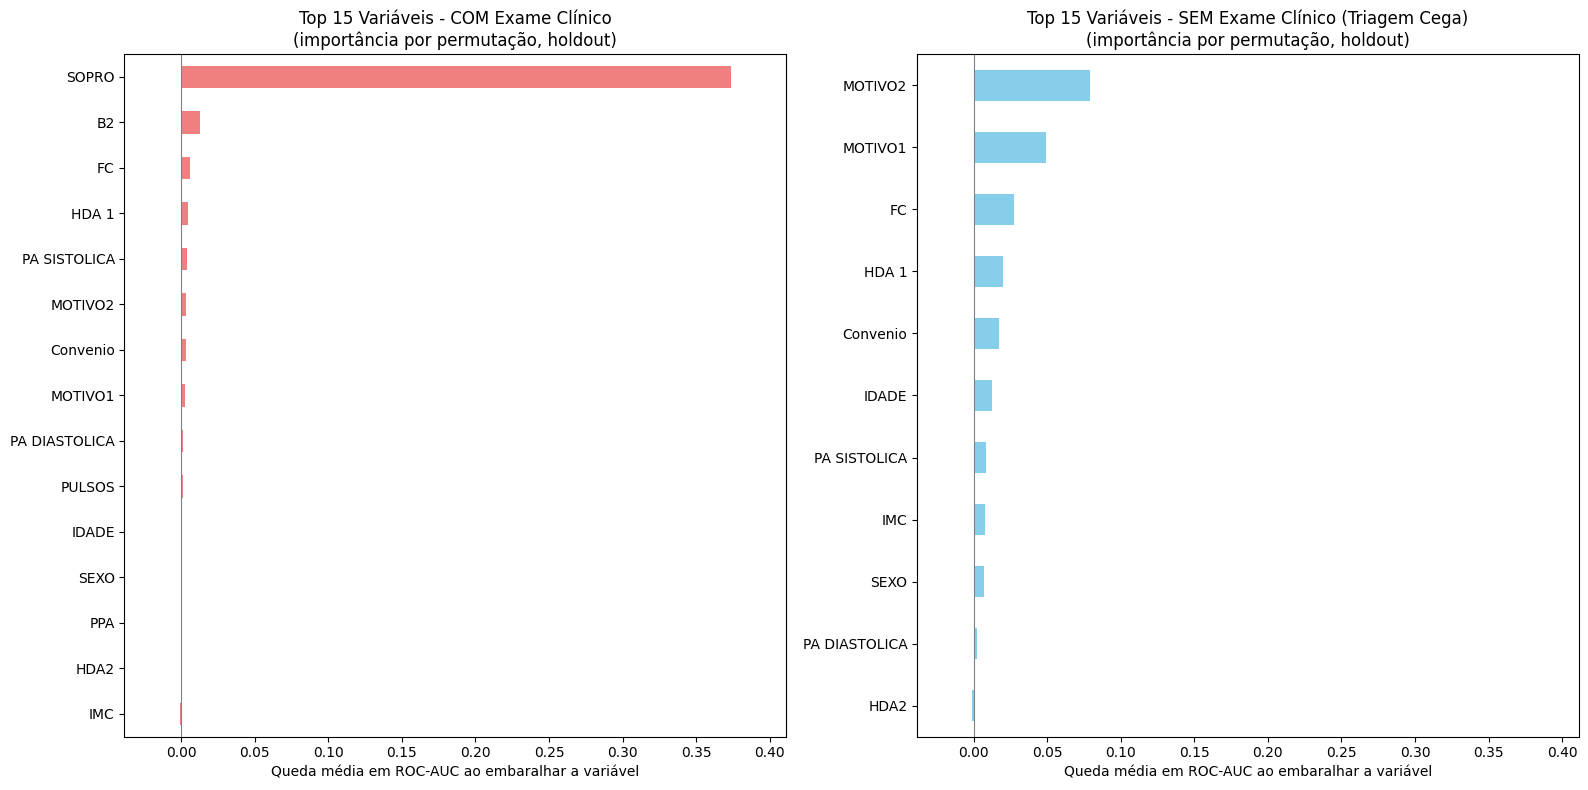

In [4]:
"""
Pipeline de limpeza e modelagem para triagem de cardiopatia infantil (UCMF).

Compara duas abordagens via validação cruzada + avaliação final em holdout:
  - Cenário A: modelo COM achados de exame clínico (sopro, pulsos, B2, PPA)
  - Cenário B: modelo SEM esses achados, simulando uma triagem "cega"
                (sem depender de auscultação especializada)

Mudanças da revisão anterior (mantidas):
  - Peso e Altura removidas do conjunto de variáveis preditoras (ver
    COLS_REMOVER_SEMPRE). Mantém-se o IMC, derivado delas, como resumo.
  - Pipeline numérico padroniza ANTES de imputar (StandardScaler ->
    KNNImputer), para que a distância usada pelo KNNImputer não seja
    dominada por variáveis em escalas maiores (ex: FC, 30-250) sobre
    variáveis em escalas menores (ex: IDADE, IMC).
  - Gradient Boosting recebe sample_weight balanceado manualmente (é o único
    modelo aqui sem class_weight nativo).
  - Holdout (20%, estratificado) separado ANTES da validação cruzada e nunca
    usado na seleção/comparação de modelos.
  - Teste pareado (t de Student) comparando o ROC-AUC dos cenários A/B fold a
    fold, já que ambos usam os mesmos splits de CV.
  - Importância de variáveis por permutação (no holdout), não por impureza
    (Gini), para não favorecer artificialmente variáveis contínuas/de alta
    cardinalidade.
  - XGBoost com n_jobs=1 para não competir por threads com o paralelismo do
    cross_validate (n_jobs=-1).

Mudanças desta revisão (nova):
  - PPA: "Não Calculado" deixou de ser tratado como ausente. É um resultado
    válido (a PA provavelmente não foi medida/calculada nessa consulta) e
    carrega informação própria; tratá-lo como NaN e depois imputar por moda
    inflava artificialmente a categoria "Normal". Só "#VALUE!" (erro de
    planilha) continua sendo convertido para NaN.
  - Imputação categórica trocada de strategy='most_frequent' para
    strategy='constant' com rótulo 'NAO_INFORMADO' explícito. Várias colunas
    têm proporção alta de ausência (HDA2 ~97%, B2/SOPRO/PULSOS/PPA também
    relevantes) e "most_frequent" simplesmente apagava esse sinal dentro da
    categoria mais comum — em dado clínico, "não informado/não medido" não
    costuma ser aleatório.
  - Corrigido vazamento de dados na normalização de alta cardinalidade de
    Convenio: antes, as categorias "frequentes o bastante para não virarem
    OUTRO" eram decididas sobre a base inteira (incluindo o holdout) antes
    do train_test_split. Agora essa decisão usa SOMENTE o conjunto de
    treino, e o mesmo conjunto de categorias é depois aplicado ao holdout —
    igual ao que já acontecia com o scaler/imputer dentro do Pipeline.
  - Corrigido bug de reprodutibilidade na correção de século das datas: a
    comparação usada para decidir se uma data de nascimento estava no
    "século errado" usava pd.Timestamp.now() (o momento em que o script é
    executado), o que podia mudar o resultado da limpeza dependendo de QUANDO
    o script roda. Agora a data de nascimento é comparada com a própria data
    de atendimento da linha (referência fixa, vinda do dado), e só a data de
    atendimento em si continua sendo comparada com "agora" — comparação que,
    nesse caso, é estável (uma consulta já registrada no passado não passa a
    ser "futura" de novo com o tempo).
"""

import logging
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.base import clone
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import roc_auc_score, f1_score, recall_score
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(message)s')
log = logging.getLogger(__name__)


# ==========================================
# CONFIGURAÇÃO
# ==========================================
CSV_PATH = 'UCMF_raw.csv'
TARGET = 'NORMAL X ANORMAL'
RANDOM_STATE = 42
N_SPLITS = 5
N_REPEATS = 1          # aumente (ex: 5) para um teste estatístico mais robusto entre cenários
HOLDOUT_SIZE = 0.2
N_JOBS_CV = -1          # paralelismo do cross_validate (modelos internos usam 1 thread, ver XGBoost)
TOP_N_CONVENIO = 15      # nº de categorias de Convenio mantidas; o resto vira 'OUTRO'
ROTULO_NAO_INFORMADO = 'NAO_INFORMADO'

# Achados que dependem de exame físico especializado (auscultação/palpação por
# profissional treinado). PPA é a classificação percentilada derivada de
# PA SISTOLICA/PA DIASTOLICA + idade/sexo, então também entra como "rótulo de
# exame". Os valores brutos de PA SISTOLICA/PA DIASTOLICA/FC permanecem no
# Cenário B porque podem ser medidos em qualquer triagem básica.
VARS_EXAME = ['SOPRO', 'PULSOS', 'B2', 'PPA']

# Peso e Altura removidas: ~35-45% dos registros trazem 0 como sentinela de
# "não medido" (já tratado como NaN em aplicar_limites_clinicos), o que torna
# essas colunas brutas pouco confiáveis isoladamente. Mantemos o IMC -
# calculado a partir delas antes de descartá-las - como resumo derivado.
COLS_REMOVER_SEMPRE = ['Peso', 'Altura']

MODELO_PARA_IMPORTANCIA = 'Random Forest'


# ==========================================
# 1. FUNÇÕES DE LIMPEZA E ENGENHARIA
# ==========================================
def normalizar_texto_categoria(serie, rotulo_nulo=ROTULO_NAO_INFORMADO):
    """Preenche nulos ANTES de qualquer conversão de texto (evita o clássico
    bug de NaN virar a string literal "nan") e padroniza maiúsculas/espaços.

    Não agrupa categorias raras em 'OUTRO' — isso fica para depois do split
    treino/holdout (ver `ajustar_categorias_raras` / `aplicar_categorias_raras`),
    já que decidir quais categorias são "raras" usando dados do holdout seria
    um vazamento de informação, ainda que pequeno.
    """
    return serie.fillna(rotulo_nulo).str.strip().str.upper()


def ajustar_categorias_raras(serie_treino, top_n=15):
    """Aprende, usando SOMENTE o conjunto de treino, quais categorias são
    frequentes o bastante para manter sua própria coluna dummy. Retorna o
    índice de categorias a manter; o restante vira 'OUTRO' em
    `aplicar_categorias_raras`. Mantém o resultado fora do one-hot encoding
    cego a centenas de variantes de digitação (ex: 'Camed' / 'CAMED'), que
    além de caras computacionalmente inflam artificialmente a importância de
    variáveis no Random Forest (a importância de Gini favorece variáveis de
    alta cardinalidade)."""
    return serie_treino.value_counts().nlargest(top_n).index


def aplicar_categorias_raras(serie, categorias_mantidas, rotulo_outro='OUTRO'):
    """Aplica o conjunto de categorias aprendido em `ajustar_categorias_raras`
    a uma série (treino OU holdout) — garante que treino e holdout usem
    exatamente a mesma definição de 'OUTRO'."""
    return serie.where(serie.isin(categorias_mantidas), rotulo_outro)


def carregar_e_limpar_dados(filepath):
    df = pd.read_csv(filepath)

    # Importante: NÃO usamos .astype(str) em colunas inteiras. Fazer isso
    # pode transformar valores ausentes reais na string literal "nan", que
    # depois escapa de qualquer tratamento de nulo. O acessor .str já
    # propaga NaN corretamente sem precisar dessa conversão.
    colunas_texto = df.select_dtypes(include=['object']).columns
    for col in colunas_texto:
        df[col] = df[col].str.strip()

    # Conferido contra value_counts() reais da base: as únicas duplicatas de
    # grafia existentes em NORMAL X ANORMAL ('anormal', 'Normais'), SOPRO
    # ('sistólico'/'Sistólico', 'contínuo'/'Contínuo') e PULSOS
    # ('NORMAIS'/'Normais', 'AMPLOS'/'Amplos') já são unificadas pelo código
    # abaixo. Atenção: nos value_counts() mais recentes da base essas
    # variantes em minúsculo/caixa alta específicas não aparecem mais — as
    # linhas abaixo são mantidas de forma defensiva (são idempotentes, não
    # fazem mal se não houver match), mas vale reconferir contra o CSV bruto
    # se a fonte de dados mudar.
    df['NORMAL X ANORMAL'] = df['NORMAL X ANORMAL'].str.title().replace('Normais', 'Normal')
    df['SEXO'] = df['SEXO'].str.upper().str[0].replace('I', np.nan)
    df['SOPRO'] = df['SOPRO'].replace({'sistólico': 'Sistólico', 'contínuo': 'Contínuo'})
    df['PULSOS'] = df['PULSOS'].replace({'NORMAIS': 'Normais', 'AMPLOS': 'Amplos'})

    # "Não Calculado" passa a ser tratado como categoria válida, não como
    # ausente: é um resultado real (a PA provavelmente não foi medida/
    # calculada nessa consulta) e carrega informação própria. Tratá-lo como
    # NaN e depois imputar por moda inflava artificialmente a categoria
    # "Normal" (a mais comum entre os valores realmente calculados). Só
    # "#VALUE!" (erro de planilha, não um resultado clínico) vira NaN.
    df['PPA'] = df['PPA'].replace('#VALUE!', np.nan)

    # Limpeza básica de Convenio (nulos explícitos + padronização de texto).
    # O agrupamento de categorias raras em 'OUTRO' é feito depois do split
    # treino/holdout, em main, para não vazar informação do holdout.
    df['Convenio'] = normalizar_texto_categoria(df['Convenio'])

    return df


def tratar_datas_e_idade(df):
    def parse_data_com_correcao_seculo(serie, referencia):
        """Corrige datas com ano de 2 dígitos interpretado no século errado
        (ex: "27" virando 2027 em vez de 1927). `referencia` é o ponto de
        corte: qualquer data parseada que caia DEPOIS dela é considerada erro
        de século e recua 100 anos. Importante: `referencia` deve ser algo
        determinado pelo próprio dado (não pd.Timestamp.now()) sempre que
        possível, para que o resultado da limpeza não dependa de QUANDO o
        script é executado."""
        datas = pd.to_datetime(serie, format='%d/%m/%y', errors='coerce')
        futuras = datas > referencia
        datas.loc[futuras] = datas.loc[futuras] - pd.DateOffset(years=100)
        return datas

    # Atendimento: comparar com "agora" aqui é razoável e estável — uma data
    # de atendimento já registrada no passado não passa a ser "futura" de
    # novo conforme o tempo passa (diferente de comparar a DATA DE
    # NASCIMENTO com "agora", que é o que causava o bug de reprodutibilidade).
    atend = parse_data_com_correcao_seculo(df['Atendimento'], pd.Timestamp.now())

    # DN agora é comparado com a própria data de atendimento da linha — uma
    # referência fixa, vinda do dado, em vez de pd.Timestamp.now(). Ninguém
    # nasce depois da própria consulta, então esse critério é tão correto
    # quanto comparar com "hoje" para detectar erro de século, mas sem
    # depender do momento de execução do script.
    dn = parse_data_com_correcao_seculo(df['DN'], atend)

    linhas_invalidas = df['IDADE'].isna() & (dn.isna() | atend.isna())
    df = df[~linhas_invalidas].copy()
    dn = dn[~linhas_invalidas]
    atend = atend[~linhas_invalidas]

    idade_calc = (atend - dn).dt.days / 365.25
    df['IDADE'] = df['IDADE'].fillna(idade_calc).round(2)

    return df.drop(columns=['Atendimento', 'DN', 'ID'], errors='ignore')


def aplicar_limites_clinicos(df):
    df.loc[(df['IDADE'] < 0) | (df['IDADE'] > 19), 'IDADE'] = np.nan
    df.loc[df['Peso'] <= 0, 'Peso'] = np.nan
    df.loc[df['Altura'] <= 0, 'Altura'] = np.nan

    df['PA SISTOLICA'] = pd.to_numeric(df['PA SISTOLICA'], errors='coerce')
    df.loc[(df['PA SISTOLICA'] <= 0) | (df['PA SISTOLICA'] > 300), 'PA SISTOLICA'] = np.nan

    df['PA DIASTOLICA'] = pd.to_numeric(df['PA DIASTOLICA'], errors='coerce')
    df.loc[(df['PA DIASTOLICA'] <= 0) | (df['PA DIASTOLICA'] > 200), 'PA DIASTOLICA'] = np.nan

    df['FC'] = pd.to_numeric(df['FC'], errors='coerce')
    df.loc[(df['FC'] < 30) | (df['FC'] > 250), 'FC'] = np.nan

    # Recalcula o IMC a partir do Peso/Altura já limpos em vez de confiar no
    # valor original do CSV.
    altura_m = df['Altura'] / 100
    df['IMC'] = np.where(altura_m > 0, df['Peso'] / (altura_m ** 2), np.nan)
    df.loc[(df['IMC'] < 5) | (df['IMC'] > 45), 'IMC'] = np.nan

    # Peso e Altura saem do conjunto de variáveis (ver COLS_REMOVER_SEMPRE no
    # topo do arquivo); o IMC, já calculado acima, permanece como resumo.
    return df.drop(columns=COLS_REMOVER_SEMPRE, errors='ignore')


# ==========================================
# 2. FUNÇÕES DE MODELAGEM
# ==========================================
def montar_X_y(df, drop_cols=None, target=TARGET):
    df = df.drop(columns=drop_cols or [], errors='ignore')
    y = df[target]
    X = df.drop(columns=[target])
    return X, y


def inferir_tipos_coluna(X):
    num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    # Garante que nenhuma coluna está sendo descartada silenciosamente pelo
    # ColumnTransformer (remainder='drop' por padrão) por causa de um dtype
    # não mapeado em num_cols/cat_cols.
    faltantes = set(X.columns) - set(num_cols) - set(cat_cols)
    assert not faltantes, (
        f"Colunas com dtype não tratado seriam descartadas silenciosamente: {faltantes}"
    )
    return num_cols, cat_cols


def construir_pipeline(num_cols, cat_cols, modelo):
    # Padronizamos ANTES de imputar: o StandardScaler do sklearn ignora NaN
    # ao calcular média/desvio e os mantém no transform, então o KNNImputer
    # passa a calcular distância já no espaço padronizado — evita que
    # variáveis em escala maior (ex: FC) dominem a escolha de vizinhos sobre
    # variáveis em escala menor (ex: IMC, IDADE). Isso não afeta o ajuste de
    # modelos baseados em árvore, então o mesmo pipeline serve para todos.
    numeric_transformer = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('knn', KNNImputer(n_neighbors=5)),
    ])

    categorical_transformer = Pipeline(steps=[
        # Trocado de strategy='most_frequent' para um rótulo constante
        # explícito. Várias colunas categóricas têm proporção alta de
        # ausência (ex: HDA2 ~97%, e parcelas relevantes em B2, SOPRO,
        # PULSOS, PPA) — "most_frequent" simplesmente absorvia essas linhas
        # dentro da categoria mais comum, apagando o sinal de "isso não foi
        # informado/medido", que em dado clínico raramente é aleatório.
        ('imputer', SimpleImputer(strategy='constant', fill_value=ROTULO_NAO_INFORMADO)),
        ('ohe', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, num_cols),
            ('cat', categorical_transformer, cat_cols)
        ])

    return Pipeline(steps=[('preprocessor', preprocessor), ('classifier', modelo)])


def _cross_validate_compat(pipeline, X, y, cv, scoring, sample_weight=None, n_jobs=N_JOBS_CV):
    """Wrapper para cross_validate que roteia sample_weight ao classificador
    final do pipeline (ex: Gradient Boosting). Tenta a API atual (params=) e
    cai para fit_params= em versões mais antigas do scikit-learn."""
    fit_kwargs = {'classifier__sample_weight': sample_weight} if sample_weight is not None else None
    try:
        return cross_validate(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=n_jobs, params=fit_kwargs)
    except TypeError:
        return cross_validate(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=n_jobs, fit_params=fit_kwargs)


def avaliar_modelos_cv(X, y, num_cols, cat_cols):
    sample_weight_balanceado = compute_sample_weight('balanced', y)
    scale_pos_weight = (y == 0).sum() / max((y == 1).sum(), 1)

    modelos = {
        "Regressão Logística": LogisticRegression(
            max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'),
        "SVC": SVC(
            kernel='rbf', random_state=RANDOM_STATE, class_weight='balanced'),
        "Random Forest": RandomForestClassifier(
            n_estimators=100, random_state=RANDOM_STATE, class_weight='balanced'),
        # GradientBoostingClassifier não tem class_weight nativo (diferente
        # dos demais modelos do sklearn aqui); por isso recebe sample_weight
        # balanceado manualmente via _cross_validate_compat mais abaixo.
        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=100, random_state=RANDOM_STATE),
        "XGBoost": XGBClassifier(
            n_estimators=100, random_state=RANDOM_STATE, eval_metric='logloss',
            scale_pos_weight=scale_pos_weight, n_jobs=1),  # n_jobs=1: evita threads
            # internas do XGBoost disputando CPU com o paralelismo do cross_validate
    }

    cv = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=RANDOM_STATE)
    resultados = {}

    log.info(f"{'Modelo':<22} | {'ROC-AUC':<16} | {'F1-Score':<16} | {'Recall (Anormal)'}")
    log.info("-" * 78)

    for nome, modelo in modelos.items():
        pipeline = construir_pipeline(num_cols, cat_cols, modelo)
        sw = sample_weight_balanceado if nome == "Gradient Boosting" else None
        scores = _cross_validate_compat(
            pipeline, X, y, cv=cv, scoring=['roc_auc', 'f1', 'recall'], sample_weight=sw
        )

        roc_auc, roc_std = scores['test_roc_auc'].mean(), scores['test_roc_auc'].std()
        f1, f1_std = scores['test_f1'].mean(), scores['test_f1'].std()
        recall, recall_std = scores['test_recall'].mean(), scores['test_recall'].std()

        # IMPORTANTE: este 'pipeline' NÃO foi treinado aqui. cross_validate()
        # clona o estimador internamente para cada fold e descarta os clones
        # ao final. O fit() real acontece em avaliar_holdout(), que é quem
        # efetivamente precisa do modelo treinado.
        resultados[nome] = {
            'pipeline': pipeline,
            'sample_weight': sw,
            'roc_auc': scores['test_roc_auc'],
            'f1': scores['test_f1'],
            'recall': scores['test_recall'],
        }

        log.info(f"{nome:<22} | {roc_auc:.4f} +/- {roc_std:.4f} | "
                 f"{f1:.4f} +/- {f1_std:.4f} | {recall:.4f} +/- {recall_std:.4f}")

    return resultados


def comparar_cenarios(resultados_com, resultados_sem):
    """Teste pareado (t de Student) no ROC-AUC fold a fold entre os dois
    cenários. Válido porque ambos usam o mesmo y (mesmas linhas, mesmo
    target), logo o RepeatedStratifiedKFold com o mesmo random_state produz
    exatamente os mesmos splits nos dois casos.

    Aviso: com poucos folds (N_SPLITS x N_REPEATS) esse teste tem baixo poder
    estatístico — um p-valor não significativo pode simplesmente refletir
    poucas observações, não ausência de diferença real. Aumente N_REPEATS
    para um teste mais robusto.
    """
    log.info("\n" + "=" * 78)
    log.info("COMPARAÇÃO ESTATÍSTICA ENTRE CENÁRIOS (ROC-AUC, teste t pareado)")
    log.info("=" * 78)
    log.info(f"{'Modelo':<22} | {'AUC com exame':<16} | {'AUC sem exame':<16} | {'Δ':<8} | p-valor")
    log.info("-" * 86)
    for nome in resultados_com:
        a = resultados_com[nome]['roc_auc']
        b = resultados_sem[nome]['roc_auc']
        _, p = stats.ttest_rel(a, b)
        log.info(f"{nome:<22} | {a.mean():.4f}{'':<10} | {b.mean():.4f}{'':<10} | "
                 f"{a.mean() - b.mean():+.4f} | {p:.4f}")


def avaliar_holdout(nome_modelo, pipeline, X_train, y_train, X_hold, y_hold, label_cenario, sample_weight=None):
    """Treina o pipeline (já configurado, ainda não ajustado) no conjunto de
    treino e avalia no holdout — dados nunca vistos durante a validação
    cruzada de seleção de modelo. Retorna o pipeline já ajustado, para reuso
    na extração de importâncias por permutação."""
    pipeline = clone(pipeline)
    fit_kwargs = {'classifier__sample_weight': sample_weight} if sample_weight is not None else {}
    pipeline.fit(X_train, y_train, **fit_kwargs)

    if hasattr(pipeline, 'predict_proba'):
        proba = pipeline.predict_proba(X_hold)[:, 1]
    else:
        proba = pipeline.decision_function(X_hold)
    pred = pipeline.predict(X_hold)

    auc = roc_auc_score(y_hold, proba)
    f1 = f1_score(y_hold, pred)
    recall = recall_score(y_hold, pred)
    log.info(f"[Holdout | {label_cenario}] {nome_modelo}: "
             f"ROC-AUC={auc:.4f}  F1={f1:.4f}  Recall(Anormal)={recall:.4f}")
    return pipeline


def extrair_importancias(pipeline_ajustado, X_hold, y_hold, scoring='roc_auc', n_repeats=10):
    """Importância por permutação no holdout, sobre as colunas ORIGINAIS de
    entrada (a permutação embaralha colunas de X antes do ColumnTransformer,
    então o resultado já vem com os nomes reais das variáveis — sem precisar
    reconstruir nomes de dummies do one-hot, como seria necessário com
    feature_importances_)."""
    r = permutation_importance(
        pipeline_ajustado, X_hold, y_hold, scoring=scoring,
        n_repeats=n_repeats, random_state=RANDOM_STATE, n_jobs=N_JOBS_CV
    )
    importancias = pd.Series(r.importances_mean, index=X_hold.columns)
    return importancias.sort_values(ascending=True).tail(15)


def rodar_cenario(label, df_train_raw, df_holdout_raw, drop_cols):
    log.info("\n" + "=" * 78)
    log.info(label)
    log.info("=" * 78)

    X_train, y_train = montar_X_y(df_train_raw, drop_cols=drop_cols)
    num_cols, cat_cols = inferir_tipos_coluna(X_train)
    resultados = avaliar_modelos_cv(X_train, y_train, num_cols, cat_cols)

    X_hold, y_hold = montar_X_y(df_holdout_raw, drop_cols=drop_cols)
    info_modelo = resultados[MODELO_PARA_IMPORTANCIA]
    pipeline_ajustado = avaliar_holdout(
        MODELO_PARA_IMPORTANCIA, info_modelo['pipeline'], X_train, y_train,
        X_hold, y_hold, label, sample_weight=info_modelo['sample_weight']
    )
    importancias = extrair_importancias(pipeline_ajustado, X_hold, y_hold)

    return resultados, importancias


# ==========================================
# 3. EXECUÇÃO PRINCIPAL (TESTE A/B)
# ==========================================
if __name__ == "__main__":
    log.info("--- Carregando e Processando Dados ---")
    df_base = carregar_e_limpar_dados(CSV_PATH)
    df_base = tratar_datas_e_idade(df_base)
    df_base = aplicar_limites_clinicos(df_base)  # já remove Peso/Altura

    df_base = df_base.dropna(subset=[TARGET]).copy()
    df_base[TARGET] = df_base[TARGET].map({'Normal': 0, 'Anormal': 1})
    alvo_invalido = df_base[TARGET].isna()
    if alvo_invalido.any():
        log.warning(f"Aviso: {alvo_invalido.sum()} linhas descartadas por valor "
                    f"inesperado em '{TARGET}'.")
        df_base = df_base[~alvo_invalido]

    # Holdout separado ANTES de qualquer CV/seleção de modelo — fica de fora
    # de todo o processo de comparação e tuning, para uma estimativa final
    # não otimista.
    df_train_raw, df_holdout_raw = train_test_split(
        df_base, test_size=HOLDOUT_SIZE, stratify=df_base[TARGET], random_state=RANDOM_STATE
    )
    df_train_raw = df_train_raw.copy()
    df_holdout_raw = df_holdout_raw.copy()

    # Agrupamento de categorias raras de Convenio em 'OUTRO': aprendido
    # SOMENTE no treino e aplicado a ambos (ver docstring do módulo —
    # corrige vazamento de dados presente na versão anterior, que decidia
    # isso sobre a base inteira antes do split).
    categorias_convenio = ajustar_categorias_raras(df_train_raw['Convenio'], top_n=TOP_N_CONVENIO)
    df_train_raw['Convenio'] = aplicar_categorias_raras(df_train_raw['Convenio'], categorias_convenio)
    df_holdout_raw['Convenio'] = aplicar_categorias_raras(df_holdout_raw['Convenio'], categorias_convenio)

    vars_exame_presentes = [c for c in VARS_EXAME if c in df_base.columns]

    resultados_com, importancias_com = rodar_cenario(
        "CENÁRIO A: Modelo COM Variáveis de Exame Clínico",
        df_train_raw, df_holdout_raw, drop_cols=None
    )
    resultados_sem, importancias_sem = rodar_cenario(
        "CENÁRIO B: Modelo SEM Variáveis de Exame (Triagem Cega)",
        df_train_raw, df_holdout_raw, drop_cols=vars_exame_presentes
    )

    comparar_cenarios(resultados_com, resultados_sem)

    # ==========================================
    # 4. COMPARAÇÃO VISUAL DAS VARIÁVEIS
    # ==========================================
    log.info("\n--- Gerando Gráficos de Comparação ---")
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Importância por permutação pode ficar levemente negativa (ruído de
    # amostragem em variáveis sem sinal real) — o eixo X precisa acomodar
    # isso, não pode simplesmente começar em 0.
    valor_min = min(0, importancias_com.min(), importancias_sem.min())
    valor_max = max(importancias_com.max(), importancias_sem.max())
    margem = (valor_max - valor_min) * 0.1
    limite_inf, limite_sup = valor_min - margem, valor_max + margem

    importancias_com.plot(kind='barh', color='lightcoral', ax=axes[0])
    axes[0].set_title('Top 15 Variáveis - COM Exame Clínico\n(importância por permutação, holdout)')
    axes[0].set_xlabel('Queda média em ROC-AUC ao embaralhar a variável')
    axes[0].set_xlim(limite_inf, limite_sup)
    axes[0].axvline(0, color='gray', linewidth=0.8)

    importancias_sem.plot(kind='barh', color='skyblue', ax=axes[1])
    axes[1].set_title('Top 15 Variáveis - SEM Exame Clínico (Triagem Cega)\n(importância por permutação, holdout)')
    axes[1].set_xlabel('Queda média em ROC-AUC ao embaralhar a variável')
    axes[1].set_xlim(limite_inf, limite_sup)
    axes[1].axvline(0, color='gray', linewidth=0.8)

    plt.tight_layout()
    plt.savefig('comparacao_importancias.png', dpi=150, bbox_inches='tight')
    log.info("Gráfico salvo em comparacao_importancias.png")
    plt.show()

In [3]:
import pandas as pd
print(pd.crosstab(df_base['SOPRO'], df_base['NORMAL X ANORMAL'], normalize='index'))

print(pd.crosstab(df_base['MOTIVO2'], df_base['NORMAL X ANORMAL'], normalize='index'))

NORMAL X ANORMAL               0         1
SOPRO                                     
Contínuo                0.209302  0.790698
Sistolico e diastólico  0.000000  1.000000
Sistólico               0.041352  0.958648
ausente                 0.899134  0.100866
diastólico              0.000000  1.000000
NORMAL X ANORMAL                            0         1
MOTIVO2                                                
1 - Cardiopatia adquirida            0.458824  0.541176
1 - Cardiopatia congenica            0.264706  0.735294
5 - Atividade física                 0.756318  0.243682
5 - Cirurgia                         0.770319  0.229681
5 - Uso de cisaprida                 0.250000  0.750000
6 - Alterações de pulso/perfusão     0.600000  0.400000
6 - Cansaço                          0.333333  0.666667
6 - Cardiopatia na familia           0.750000  0.250000
6 - Cianose                          0.598485  0.401515
6 - Cianose e dispnéia               0.666667  0.333333
6 - Dispnéia               

In [1]:
"""
Pipeline de limpeza e modelagem para triagem de cardiopatia infantil (UCMF).

Compara três abordagens via validação cruzada + avaliação final em holdout:
  - Cenário A: modelo COM achados de exame clínico (sopro, pulsos, B2, PPA)
  - Cenário B: modelo SEM esses achados, simulando uma triagem "cega"
                (sem depender de auscultação especializada), mas ainda usando
                o motivo de encaminhamento (MOTIVO1/MOTIVO2) constante na ficha
  - Cenário C: como o B, mas também SEM motivo de encaminhamento — uma
                triagem "verdadeiramente cega", sem nenhuma impressão clínica
                prévia (nem a própria, nem a de quem encaminhou o paciente)

Mudanças da revisão anterior (mantidas):
  - Peso e Altura removidas do conjunto de variáveis preditoras (ver
    COLS_REMOVER_SEMPRE). Mantém-se o IMC, derivado delas, como resumo.
  - Pipeline numérico padroniza ANTES de imputar (StandardScaler ->
    KNNImputer), para que a distância usada pelo KNNImputer não seja
    dominada por variáveis em escalas maiores (ex: FC, 30-250) sobre
    variáveis em escalas menores (ex: IDADE, IMC).
  - Gradient Boosting recebe sample_weight balanceado manualmente (é o único
    modelo aqui sem class_weight nativo).
  - Holdout (20%, estratificado) separado ANTES da validação cruzada e nunca
    usado na seleção/comparação de modelos.
  - Teste pareado (t de Student) comparando o ROC-AUC dos cenários A/B fold a
    fold, já que ambos usam os mesmos splits de CV.
  - Importância de variáveis por permutação (no holdout), não por impureza
    (Gini), para não favorecer artificialmente variáveis contínuas/de alta
    cardinalidade.
  - XGBoost com n_jobs=1 para não competir por threads com o paralelismo do
    cross_validate (n_jobs=-1).

Mudanças desta revisão (nova):
  - PPA: "Não Calculado" deixou de ser tratado como ausente. É um resultado
    válido (a PA provavelmente não foi medida/calculada nessa consulta) e
    carrega informação própria; tratá-lo como NaN e depois imputar por moda
    inflava artificialmente a categoria "Normal". Só "#VALUE!" (erro de
    planilha) continua sendo convertido para NaN.
  - Imputação categórica trocada de strategy='most_frequent' para
    strategy='constant' com rótulo 'NAO_INFORMADO' explícito. Várias colunas
    têm proporção alta de ausência (HDA2 ~97%, B2/SOPRO/PULSOS/PPA também
    relevantes) e "most_frequent" simplesmente apagava esse sinal dentro da
    categoria mais comum — em dado clínico, "não informado/não medido" não
    costuma ser aleatório.
  - Corrigido vazamento de dados na normalização de alta cardinalidade de
    Convenio: antes, as categorias "frequentes o bastante para não virarem
    OUTRO" eram decididas sobre a base inteira (incluindo o holdout) antes
    do train_test_split. Agora essa decisão usa SOMENTE o conjunto de
    treino, e o mesmo conjunto de categorias é depois aplicado ao holdout —
    igual ao que já acontecia com o scaler/imputer dentro do Pipeline.
  - Corrigido bug de reprodutibilidade na correção de século das datas: a
    comparação usada para decidir se uma data de nascimento estava no
    "século errado" usava pd.Timestamp.now() (o momento em que o script é
    executado), o que podia mudar o resultado da limpeza dependendo de QUANDO
    o script roda. Agora a data de nascimento é comparada com a própria data
    de atendimento da linha (referência fixa, vinda do dado), e só a data de
    atendimento em si continua sendo comparada com "agora" — comparação que,
    nesse caso, é estável (uma consulta já registrada no passado não passa a
    ser "futura" de novo com o tempo).

Mudança desta revisão (mais nova):
  - Adicionado o Cenário C, sem MOTIVO1/MOTIVO2 (ver VARS_REFERENCIA). Testes
    no dataset real mostraram que essas colunas, sozinhas, levam o ROC-AUC do
    Cenário B de ~0.67 para ~0.78 — boa parte desse ganho vem do padrão geral
    de motivo de encaminhamento (ex: "Suspeita de cardiopatia" vs "Check-up"),
    não de uma categoria isolada e obviamente circular. Motivo de
    encaminhamento normalmente reflete uma impressão clínica já formada por
    OUTRO profissional antes do paciente chegar a esta base — então um
    Cenário B que mantém essas colunas não é "cego" no sentido de "nenhuma
    impressão clínica prévia", só no sentido de "sem a auscultação feita
    aqui". O Cenário C isola esse efeito, removendo também MOTIVO1/MOTIVO2,
    e dá uma estimativa do que dados puramente vitais/demográficos/
    administrativos conseguem sozinhos.
"""

import logging
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.base import clone
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import roc_auc_score, f1_score, recall_score
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(message)s')
log = logging.getLogger(__name__)


# ==========================================
# CONFIGURAÇÃO
# ==========================================
CSV_PATH = 'UCMF_raw.csv'
TARGET = 'NORMAL X ANORMAL'
RANDOM_STATE = 42
N_SPLITS = 5
N_REPEATS = 1          # aumente (ex: 5) para um teste estatístico mais robusto entre cenários
HOLDOUT_SIZE = 0.2
N_JOBS_CV = 1          # paralelismo do cross_validate (modelos internos usam 1 thread, ver XGBoost)
TOP_N_CONVENIO = 15      # nº de categorias de Convenio mantidas; o resto vira 'OUTRO'
ROTULO_NAO_INFORMADO = 'NAO_INFORMADO'

# Achados que dependem de exame físico especializado (auscultação/palpação por
# profissional treinado). PPA é a classificação percentilada derivada de
# PA SISTOLICA/PA DIASTOLICA + idade/sexo, então também entra como "rótulo de
# exame". Os valores brutos de PA SISTOLICA/PA DIASTOLICA/FC permanecem no
# Cenário B porque podem ser medidos em qualquer triagem básica.
VARS_EXAME = ['SOPRO', 'PULSOS', 'B2', 'PPA']

# Motivo de encaminhamento. Embora não seja um "achado de exame" no sentido
# estrito, costuma refletir uma impressão clínica já formada por OUTRO
# profissional (ex: MOTIVO2 = "Sopro" geralmente significa que alguém já
# ouviu um sopro antes de encaminhar o paciente para esta base). Por isso
# entra como variável removida no Cenário C, que busca isolar o que dados
# puramente vitais/demográficos/administrativos conseguem prever por si só,
# sem se apoiar — direta ou indiretamente — em nenhuma impressão clínica.
VARS_REFERENCIA = ['MOTIVO1', 'MOTIVO2']

# Peso e Altura removidas: ~35-45% dos registros trazem 0 como sentinela de
# "não medido" (já tratado como NaN em aplicar_limites_clinicos), o que torna
# essas colunas brutas pouco confiáveis isoladamente. Mantemos o IMC -
# calculado a partir delas antes de descartá-las - como resumo derivado.
COLS_REMOVER_SEMPRE = ['Peso', 'Altura']

MODELO_PARA_IMPORTANCIA = 'Random Forest'


# ==========================================
# 1. FUNÇÕES DE LIMPEZA E ENGENHARIA
# ==========================================
def normalizar_texto_categoria(serie, rotulo_nulo=ROTULO_NAO_INFORMADO):
    """Preenche nulos ANTES de qualquer conversão de texto (evita o clássico
    bug de NaN virar a string literal "nan") e padroniza maiúsculas/espaços.

    Não agrupa categorias raras em 'OUTRO' — isso fica para depois do split
    treino/holdout (ver `ajustar_categorias_raras` / `aplicar_categorias_raras`),
    já que decidir quais categorias são "raras" usando dados do holdout seria
    um vazamento de informação, ainda que pequeno.
    """
    return serie.fillna(rotulo_nulo).str.strip().str.upper()


def ajustar_categorias_raras(serie_treino, top_n=15):
    """Aprende, usando SOMENTE o conjunto de treino, quais categorias são
    frequentes o bastante para manter sua própria coluna dummy. Retorna o
    índice de categorias a manter; o restante vira 'OUTRO' em
    `aplicar_categorias_raras`. Mantém o resultado fora do one-hot encoding
    cego a centenas de variantes de digitação (ex: 'Camed' / 'CAMED'), que
    além de caras computacionalmente inflam artificialmente a importância de
    variáveis no Random Forest (a importância de Gini favorece variáveis de
    alta cardinalidade)."""
    return serie_treino.value_counts().nlargest(top_n).index


def aplicar_categorias_raras(serie, categorias_mantidas, rotulo_outro='OUTRO'):
    """Aplica o conjunto de categorias aprendido em `ajustar_categorias_raras`
    a uma série (treino OU holdout) — garante que treino e holdout usem
    exatamente a mesma definição de 'OUTRO'."""
    return serie.where(serie.isin(categorias_mantidas), rotulo_outro)


def carregar_e_limpar_dados(filepath):
    df = pd.read_csv(filepath)

    # Importante: NÃO usamos .astype(str) em colunas inteiras. Fazer isso
    # pode transformar valores ausentes reais na string literal "nan", que
    # depois escapa de qualquer tratamento de nulo. O acessor .str já
    # propaga NaN corretamente sem precisar dessa conversão.
    colunas_texto = df.select_dtypes(include=['object']).columns
    for col in colunas_texto:
        df[col] = df[col].str.strip()

    # Conferido contra value_counts() reais da base: as únicas duplicatas de
    # grafia existentes em NORMAL X ANORMAL ('anormal', 'Normais'), SOPRO
    # ('sistólico'/'Sistólico', 'contínuo'/'Contínuo') e PULSOS
    # ('NORMAIS'/'Normais', 'AMPLOS'/'Amplos') já são unificadas pelo código
    # abaixo. Atenção: nos value_counts() mais recentes da base essas
    # variantes em minúsculo/caixa alta específicas não aparecem mais — as
    # linhas abaixo são mantidas de forma defensiva (são idempotentes, não
    # fazem mal se não houver match), mas vale reconferir contra o CSV bruto
    # se a fonte de dados mudar.
    df['NORMAL X ANORMAL'] = df['NORMAL X ANORMAL'].str.title().replace('Normais', 'Normal')
    df['SEXO'] = df['SEXO'].str.upper().str[0].replace('I', np.nan)
    df['SOPRO'] = df['SOPRO'].replace({'sistólico': 'Sistólico', 'contínuo': 'Contínuo'})
    df['PULSOS'] = df['PULSOS'].replace({'NORMAIS': 'Normais', 'AMPLOS': 'Amplos'})

    # "Não Calculado" passa a ser tratado como categoria válida, não como
    # ausente: é um resultado real (a PA provavelmente não foi medida/
    # calculada nessa consulta) e carrega informação própria. Tratá-lo como
    # NaN e depois imputar por moda inflava artificialmente a categoria
    # "Normal" (a mais comum entre os valores realmente calculados). Só
    # "#VALUE!" (erro de planilha, não um resultado clínico) vira NaN.
    df['PPA'] = df['PPA'].replace('#VALUE!', np.nan)

    # Limpeza básica de Convenio (nulos explícitos + padronização de texto).
    # O agrupamento de categorias raras em 'OUTRO' é feito depois do split
    # treino/holdout, em main, para não vazar informação do holdout.
    df['Convenio'] = normalizar_texto_categoria(df['Convenio'])

    return df


def tratar_datas_e_idade(df):
    def parse_data_com_correcao_seculo(serie, referencia):
        """Corrige datas com ano de 2 dígitos interpretado no século errado
        (ex: "27" virando 2027 em vez de 1927). `referencia` é o ponto de
        corte: qualquer data parseada que caia DEPOIS dela é considerada erro
        de século e recua 100 anos. Importante: `referencia` deve ser algo
        determinado pelo próprio dado (não pd.Timestamp.now()) sempre que
        possível, para que o resultado da limpeza não dependa de QUANDO o
        script é executado."""
        datas = pd.to_datetime(serie, format='%d/%m/%y', errors='coerce')
        futuras = datas > referencia
        datas.loc[futuras] = datas.loc[futuras] - pd.DateOffset(years=100)
        return datas

    # Atendimento: comparar com "agora" aqui é razoável e estável — uma data
    # de atendimento já registrada no passado não passa a ser "futura" de
    # novo conforme o tempo passa (diferente de comparar a DATA DE
    # NASCIMENTO com "agora", que é o que causava o bug de reprodutibilidade).
    atend = parse_data_com_correcao_seculo(df['Atendimento'], pd.Timestamp.now())

    # DN agora é comparado com a própria data de atendimento da linha — uma
    # referência fixa, vinda do dado, em vez de pd.Timestamp.now(). Ninguém
    # nasce depois da própria consulta, então esse critério é tão correto
    # quanto comparar com "hoje" para detectar erro de século, mas sem
    # depender do momento de execução do script.
    dn = parse_data_com_correcao_seculo(df['DN'], atend)

    linhas_invalidas = df['IDADE'].isna() & (dn.isna() | atend.isna())
    df = df[~linhas_invalidas].copy()
    dn = dn[~linhas_invalidas]
    atend = atend[~linhas_invalidas]

    idade_calc = (atend - dn).dt.days / 365.25
    df['IDADE'] = df['IDADE'].fillna(idade_calc).round(2)

    return df.drop(columns=['Atendimento', 'DN', 'ID'], errors='ignore')


def aplicar_limites_clinicos(df):
    df.loc[(df['IDADE'] < 0) | (df['IDADE'] > 19), 'IDADE'] = np.nan
    df.loc[df['Peso'] <= 0, 'Peso'] = np.nan
    df.loc[df['Altura'] <= 0, 'Altura'] = np.nan

    df['PA SISTOLICA'] = pd.to_numeric(df['PA SISTOLICA'], errors='coerce')
    df.loc[(df['PA SISTOLICA'] <= 0) | (df['PA SISTOLICA'] > 300), 'PA SISTOLICA'] = np.nan

    df['PA DIASTOLICA'] = pd.to_numeric(df['PA DIASTOLICA'], errors='coerce')
    df.loc[(df['PA DIASTOLICA'] <= 0) | (df['PA DIASTOLICA'] > 200), 'PA DIASTOLICA'] = np.nan

    df['FC'] = pd.to_numeric(df['FC'], errors='coerce')
    df.loc[(df['FC'] < 30) | (df['FC'] > 250), 'FC'] = np.nan

    # Recalcula o IMC a partir do Peso/Altura já limpos em vez de confiar no
    # valor original do CSV.
    altura_m = df['Altura'] / 100
    df['IMC'] = np.where(altura_m > 0, df['Peso'] / (altura_m ** 2), np.nan)
    df.loc[(df['IMC'] < 5) | (df['IMC'] > 45), 'IMC'] = np.nan

    # Peso e Altura saem do conjunto de variáveis (ver COLS_REMOVER_SEMPRE no
    # topo do arquivo); o IMC, já calculado acima, permanece como resumo.
    return df.drop(columns=COLS_REMOVER_SEMPRE, errors='ignore')


# ==========================================
# 2. FUNÇÕES DE MODELAGEM
# ==========================================
def montar_X_y(df, drop_cols=None, target=TARGET):
    df = df.drop(columns=drop_cols or [], errors='ignore')
    y = df[target]
    X = df.drop(columns=[target])
    return X, y


def inferir_tipos_coluna(X):
    num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    # Garante que nenhuma coluna está sendo descartada silenciosamente pelo
    # ColumnTransformer (remainder='drop' por padrão) por causa de um dtype
    # não mapeado em num_cols/cat_cols.
    faltantes = set(X.columns) - set(num_cols) - set(cat_cols)
    assert not faltantes, (
        f"Colunas com dtype não tratado seriam descartadas silenciosamente: {faltantes}"
    )
    return num_cols, cat_cols


def construir_pipeline(num_cols, cat_cols, modelo):
    # Padronizamos ANTES de imputar: o StandardScaler do sklearn ignora NaN
    # ao calcular média/desvio e os mantém no transform, então o KNNImputer
    # passa a calcular distância já no espaço padronizado — evita que
    # variáveis em escala maior (ex: FC) dominem a escolha de vizinhos sobre
    # variáveis em escala menor (ex: IMC, IDADE). Isso não afeta o ajuste de
    # modelos baseados em árvore, então o mesmo pipeline serve para todos.
    numeric_transformer = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('knn', KNNImputer(n_neighbors=5)),
    ])

    categorical_transformer = Pipeline(steps=[
        # Trocado de strategy='most_frequent' para um rótulo constante
        # explícito. Várias colunas categóricas têm proporção alta de
        # ausência (ex: HDA2 ~97%, e parcelas relevantes em B2, SOPRO,
        # PULSOS, PPA) — "most_frequent" simplesmente absorvia essas linhas
        # dentro da categoria mais comum, apagando o sinal de "isso não foi
        # informado/medido", que em dado clínico raramente é aleatório.
        ('imputer', SimpleImputer(strategy='constant', fill_value=ROTULO_NAO_INFORMADO)),
        ('ohe', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, num_cols),
            ('cat', categorical_transformer, cat_cols)
        ])

    return Pipeline(steps=[('preprocessor', preprocessor), ('classifier', modelo)])


def _cross_validate_compat(pipeline, X, y, cv, scoring, sample_weight=None, n_jobs=N_JOBS_CV):
    """Wrapper para cross_validate que roteia sample_weight ao classificador
    final do pipeline (ex: Gradient Boosting). Tenta a API atual (params=) e
    cai para fit_params= em versões mais antigas do scikit-learn."""
    fit_kwargs = {'classifier__sample_weight': sample_weight} if sample_weight is not None else None
    try:
        return cross_validate(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=n_jobs, params=fit_kwargs)
    except TypeError:
        return cross_validate(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=n_jobs, fit_params=fit_kwargs)


def avaliar_modelos_cv(X, y, num_cols, cat_cols):
    sample_weight_balanceado = compute_sample_weight('balanced', y)
    scale_pos_weight = (y == 0).sum() / max((y == 1).sum(), 1)

    modelos = {
        "Regressão Logística": LogisticRegression(
            max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'),
        "SVC": SVC(
            kernel='rbf', random_state=RANDOM_STATE, class_weight='balanced'),
        "Random Forest": RandomForestClassifier(
            n_estimators=100, random_state=RANDOM_STATE, class_weight='balanced'),
        # GradientBoostingClassifier não tem class_weight nativo (diferente
        # dos demais modelos do sklearn aqui); por isso recebe sample_weight
        # balanceado manualmente via _cross_validate_compat mais abaixo.
        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=100, random_state=RANDOM_STATE),
        "XGBoost": XGBClassifier(
            n_estimators=100, random_state=RANDOM_STATE, eval_metric='logloss',
            scale_pos_weight=scale_pos_weight, n_jobs=1),  # n_jobs=1: evita threads
            # internas do XGBoost disputando CPU com o paralelismo do cross_validate
    }

    cv = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=RANDOM_STATE)
    resultados = {}

    log.info(f"{'Modelo':<22} | {'ROC-AUC':<16} | {'F1-Score':<16} | {'Recall (Anormal)'}")
    log.info("-" * 78)

    for nome, modelo in modelos.items():
        pipeline = construir_pipeline(num_cols, cat_cols, modelo)
        sw = sample_weight_balanceado if nome == "Gradient Boosting" else None
        scores = _cross_validate_compat(
            pipeline, X, y, cv=cv, scoring=['roc_auc', 'f1', 'recall'], sample_weight=sw
        )

        roc_auc, roc_std = scores['test_roc_auc'].mean(), scores['test_roc_auc'].std()
        f1, f1_std = scores['test_f1'].mean(), scores['test_f1'].std()
        recall, recall_std = scores['test_recall'].mean(), scores['test_recall'].std()

        # IMPORTANTE: este 'pipeline' NÃO foi treinado aqui. cross_validate()
        # clona o estimador internamente para cada fold e descarta os clones
        # ao final. O fit() real acontece em avaliar_holdout(), que é quem
        # efetivamente precisa do modelo treinado.
        resultados[nome] = {
            'pipeline': pipeline,
            'sample_weight': sw,
            'roc_auc': scores['test_roc_auc'],
            'f1': scores['test_f1'],
            'recall': scores['test_recall'],
        }

        log.info(f"{nome:<22} | {roc_auc:.4f} +/- {roc_std:.4f} | "
                 f"{f1:.4f} +/- {f1_std:.4f} | {recall:.4f} +/- {recall_std:.4f}")

    return resultados


def comparar_cenarios(resultados_por_cenario):
    """Teste pareado (t de Student) no ROC-AUC fold a fold entre TODOS os
    pares de cenários fornecidos. Válido porque todos os cenários usam o
    mesmo y (mesmas linhas, mesmo target), logo o RepeatedStratifiedKFold com
    o mesmo random_state produz exatamente os mesmos splits em todos eles.

    `resultados_por_cenario` é um dict {label_do_cenario: resultados}, onde
    `resultados` é o dict retornado por `avaliar_modelos_cv` (uma entrada por
    modelo, com a chave 'roc_auc' contendo os scores fold a fold).

    Aviso: com poucos folds (N_SPLITS x N_REPEATS) esse teste tem baixo poder
    estatístico — um p-valor não significativo pode simplesmente refletir
    poucas observações, não ausência de diferença real. Aumente N_REPEATS
    para um teste mais robusto.
    """
    from itertools import combinations

    labels = list(resultados_por_cenario.keys())
    nomes_modelos = list(next(iter(resultados_por_cenario.values())).keys())

    for label_a, label_b in combinations(labels, 2):
        log.info("\n" + "=" * 78)
        log.info(f"COMPARAÇÃO ESTATÍSTICA: {label_a}  vs.  {label_b}  (ROC-AUC, teste t pareado)")
        log.info("=" * 78)
        log.info(f"{'Modelo':<22} | {'AUC ' + label_a[:14]:<19} | {'AUC ' + label_b[:14]:<19} | {'Δ':<8} | p-valor")
        log.info("-" * 88)
        for nome in nomes_modelos:
            a = resultados_por_cenario[label_a][nome]['roc_auc']
            b = resultados_por_cenario[label_b][nome]['roc_auc']
            _, p = stats.ttest_rel(a, b)
            log.info(f"{nome:<22} | {a.mean():.4f}{'':<13} | {b.mean():.4f}{'':<13} | "
                     f"{a.mean() - b.mean():+.4f} | {p:.4f}")


def avaliar_holdout(nome_modelo, pipeline, X_train, y_train, X_hold, y_hold, label_cenario, sample_weight=None):
    """Treina o pipeline (já configurado, ainda não ajustado) no conjunto de
    treino e avalia no holdout — dados nunca vistos durante a validação
    cruzada de seleção de modelo. Retorna o pipeline já ajustado, para reuso
    na extração de importâncias por permutação."""
    pipeline = clone(pipeline)
    fit_kwargs = {'classifier__sample_weight': sample_weight} if sample_weight is not None else {}
    pipeline.fit(X_train, y_train, **fit_kwargs)

    if hasattr(pipeline, 'predict_proba'):
        proba = pipeline.predict_proba(X_hold)[:, 1]
    else:
        proba = pipeline.decision_function(X_hold)
    pred = pipeline.predict(X_hold)

    auc = roc_auc_score(y_hold, proba)
    f1 = f1_score(y_hold, pred)
    recall = recall_score(y_hold, pred)
    log.info(f"[Holdout | {label_cenario}] {nome_modelo}: "
             f"ROC-AUC={auc:.4f}  F1={f1:.4f}  Recall(Anormal)={recall:.4f}")
    return pipeline


def extrair_importancias(pipeline_ajustado, X_hold, y_hold, scoring='roc_auc', n_repeats=10):
    """Importância por permutação no holdout, sobre as colunas ORIGINAIS de
    entrada (a permutação embaralha colunas de X antes do ColumnTransformer,
    então o resultado já vem com os nomes reais das variáveis — sem precisar
    reconstruir nomes de dummies do one-hot, como seria necessário com
    feature_importances_)."""
    r = permutation_importance(
        pipeline_ajustado, X_hold, y_hold, scoring=scoring,
        n_repeats=n_repeats, random_state=RANDOM_STATE, n_jobs=N_JOBS_CV
    )
    importancias = pd.Series(r.importances_mean, index=X_hold.columns)
    return importancias.sort_values(ascending=True).tail(15)


def rodar_cenario(label, df_train_raw, df_holdout_raw, drop_cols):
    log.info("\n" + "=" * 78)
    log.info(label)
    log.info("=" * 78)

    X_train, y_train = montar_X_y(df_train_raw, drop_cols=drop_cols)
    num_cols, cat_cols = inferir_tipos_coluna(X_train)
    resultados = avaliar_modelos_cv(X_train, y_train, num_cols, cat_cols)

    X_hold, y_hold = montar_X_y(df_holdout_raw, drop_cols=drop_cols)
    info_modelo = resultados[MODELO_PARA_IMPORTANCIA]
    pipeline_ajustado = avaliar_holdout(
        MODELO_PARA_IMPORTANCIA, info_modelo['pipeline'], X_train, y_train,
        X_hold, y_hold, label, sample_weight=info_modelo['sample_weight']
    )
    importancias = extrair_importancias(pipeline_ajustado, X_hold, y_hold)

    return resultados, importancias


# ==========================================
# 3. EXECUÇÃO PRINCIPAL (TESTE A/B/C)
# ==========================================
if __name__ == "__main__":
    log.info("--- Carregando e Processando Dados ---")
    df_base = carregar_e_limpar_dados(CSV_PATH)
    df_base = tratar_datas_e_idade(df_base)
    df_base = aplicar_limites_clinicos(df_base)  # já remove Peso/Altura

    df_base = df_base.dropna(subset=[TARGET]).copy()
    df_base[TARGET] = df_base[TARGET].map({'Normal': 0, 'Anormal': 1})
    alvo_invalido = df_base[TARGET].isna()
    if alvo_invalido.any():
        log.warning(f"Aviso: {alvo_invalido.sum()} linhas descartadas por valor "
                    f"inesperado em '{TARGET}'.")
        df_base = df_base[~alvo_invalido]

    # Holdout separado ANTES de qualquer CV/seleção de modelo — fica de fora
    # de todo o processo de comparação e tuning, para uma estimativa final
    # não otimista.
    df_train_raw, df_holdout_raw = train_test_split(
        df_base, test_size=HOLDOUT_SIZE, stratify=df_base[TARGET], random_state=RANDOM_STATE
    )
    df_train_raw = df_train_raw.copy()
    df_holdout_raw = df_holdout_raw.copy()

    # Agrupamento de categorias raras de Convenio em 'OUTRO': aprendido
    # SOMENTE no treino e aplicado a ambos (ver docstring do módulo —
    # corrige vazamento de dados presente na versão anterior, que decidia
    # isso sobre a base inteira antes do split).
    categorias_convenio = ajustar_categorias_raras(df_train_raw['Convenio'], top_n=TOP_N_CONVENIO)
    df_train_raw['Convenio'] = aplicar_categorias_raras(df_train_raw['Convenio'], categorias_convenio)
    df_holdout_raw['Convenio'] = aplicar_categorias_raras(df_holdout_raw['Convenio'], categorias_convenio)

    vars_exame_presentes = [c for c in VARS_EXAME if c in df_base.columns]
    vars_referencia_presentes = [c for c in VARS_REFERENCIA if c in df_base.columns]

    resultados_A, importancias_A = rodar_cenario(
        "CENÁRIO A: Modelo COM Variáveis de Exame Clínico",
        df_train_raw, df_holdout_raw, drop_cols=None
    )
    resultados_B, importancias_B = rodar_cenario(
        "CENÁRIO B: Modelo SEM Exame Clínico (mantém motivo de encaminhamento)",
        df_train_raw, df_holdout_raw, drop_cols=vars_exame_presentes
    )
    resultados_C, importancias_C = rodar_cenario(
        "CENÁRIO C: Triagem Verdadeiramente Cega (sem exame E sem motivo de encaminhamento)",
        df_train_raw, df_holdout_raw, drop_cols=vars_exame_presentes + vars_referencia_presentes
    )

    comparar_cenarios({
        'Cenário A': resultados_A,
        'Cenário B': resultados_B,
        'Cenário C': resultados_C,
    })

    # ==========================================
    # 4. COMPARAÇÃO VISUAL DAS VARIÁVEIS
    # ==========================================
    log.info("\n--- Gerando Gráficos de Comparação ---")
    fig, axes = plt.subplots(1, 3, figsize=(22, 8))

    painéis = [
        (importancias_A, 'lightcoral', 'Top 15 Variáveis - Cenário A\n(COM exame clínico)'),
        (importancias_B, 'skyblue', 'Top 15 Variáveis - Cenário B\n(SEM exame, COM motivo encaminhamento)'),
        (importancias_C, 'mediumseagreen', 'Top 15 Variáveis - Cenário C\n(triagem verdadeiramente cega)'),
    ]

    # Importância por permutação pode ficar levemente negativa (ruído de
    # amostragem em variáveis sem sinal real) — o eixo X precisa acomodar
    # isso, não pode simplesmente começar em 0. Mesma escala nos três
    # painéis para permitir comparar a magnitude da importância entre eles.
    todas_importancias = pd.concat([p[0] for p in painéis])
    valor_min = min(0, todas_importancias.min())
    valor_max = todas_importancias.max()
    margem = (valor_max - valor_min) * 0.1
    limite_inf, limite_sup = valor_min - margem, valor_max + margem

    for ax, (importancias, cor, titulo) in zip(axes, painéis):
        importancias.plot(kind='barh', color=cor, ax=ax)
        ax.set_title(titulo + '\n(importância por permutação, holdout)')
        ax.set_xlabel('Queda média em ROC-AUC ao embaralhar a variável')
        ax.set_xlim(limite_inf, limite_sup)
        ax.axvline(0, color='gray', linewidth=0.8)

    plt.tight_layout()
    plt.savefig('comparacao_importancias.png', dpi=150, bbox_inches='tight')
    log.info("Gráfico salvo em comparacao_importancias.png")
    plt.show()

--- Carregando e Processando Dados ---

CENÁRIO A: Modelo COM Variáveis de Exame Clínico
Modelo                 | ROC-AUC          | F1-Score         | Recall (Anormal)
------------------------------------------------------------------------------
Regressão Logística    | 0.9417 +/- 0.0053 | 0.9066 +/- 0.0061 | 0.8703 +/- 0.0125


KeyboardInterrupt: 

--- Carregando e Processando Dados ---
Removidas 995 linha(s) duplicada(s) (idênticas exceto ID).
IDADE informada e idade calculada por data divergem em mais de 5 anos em 74 linha(s) (diferença máxima: 101.1 anos). IDADE informada foi mantida sem alteração em todas elas; revisão manual recomendada para decidir qual fonte confiar caso a caso.

CENÁRIO A: Modelo COM Variáveis de Exame Clínico
Modelo                 | ROC-AUC          | F1-Score         | Recall (Anormal)
------------------------------------------------------------------------------
Regressão Logística    | 0.9425 +/- 0.0053 | 0.9091 +/- 0.0066 | 0.8729 +/- 0.0109
SVC                    | 0.9392 +/- 0.0042 | 0.9105 +/- 0.0061 | 0.8737 +/- 0.0105
Random Forest          | 0.9462 +/- 0.0041 | 0.9104 +/- 0.0073 | 0.8721 +/- 0.0122
Gradient Boosting      | 0.9487 +/- 0.0047 | 0.9104 +/- 0.0065 | 0.8745 +/- 0.0106
XGBoost                | 0.9437 +/- 0.0049 | 0.9048 +/- 0.0059 | 0.8740 +/- 0.0126
[Holdout | CENÁRIO A: Modelo COM

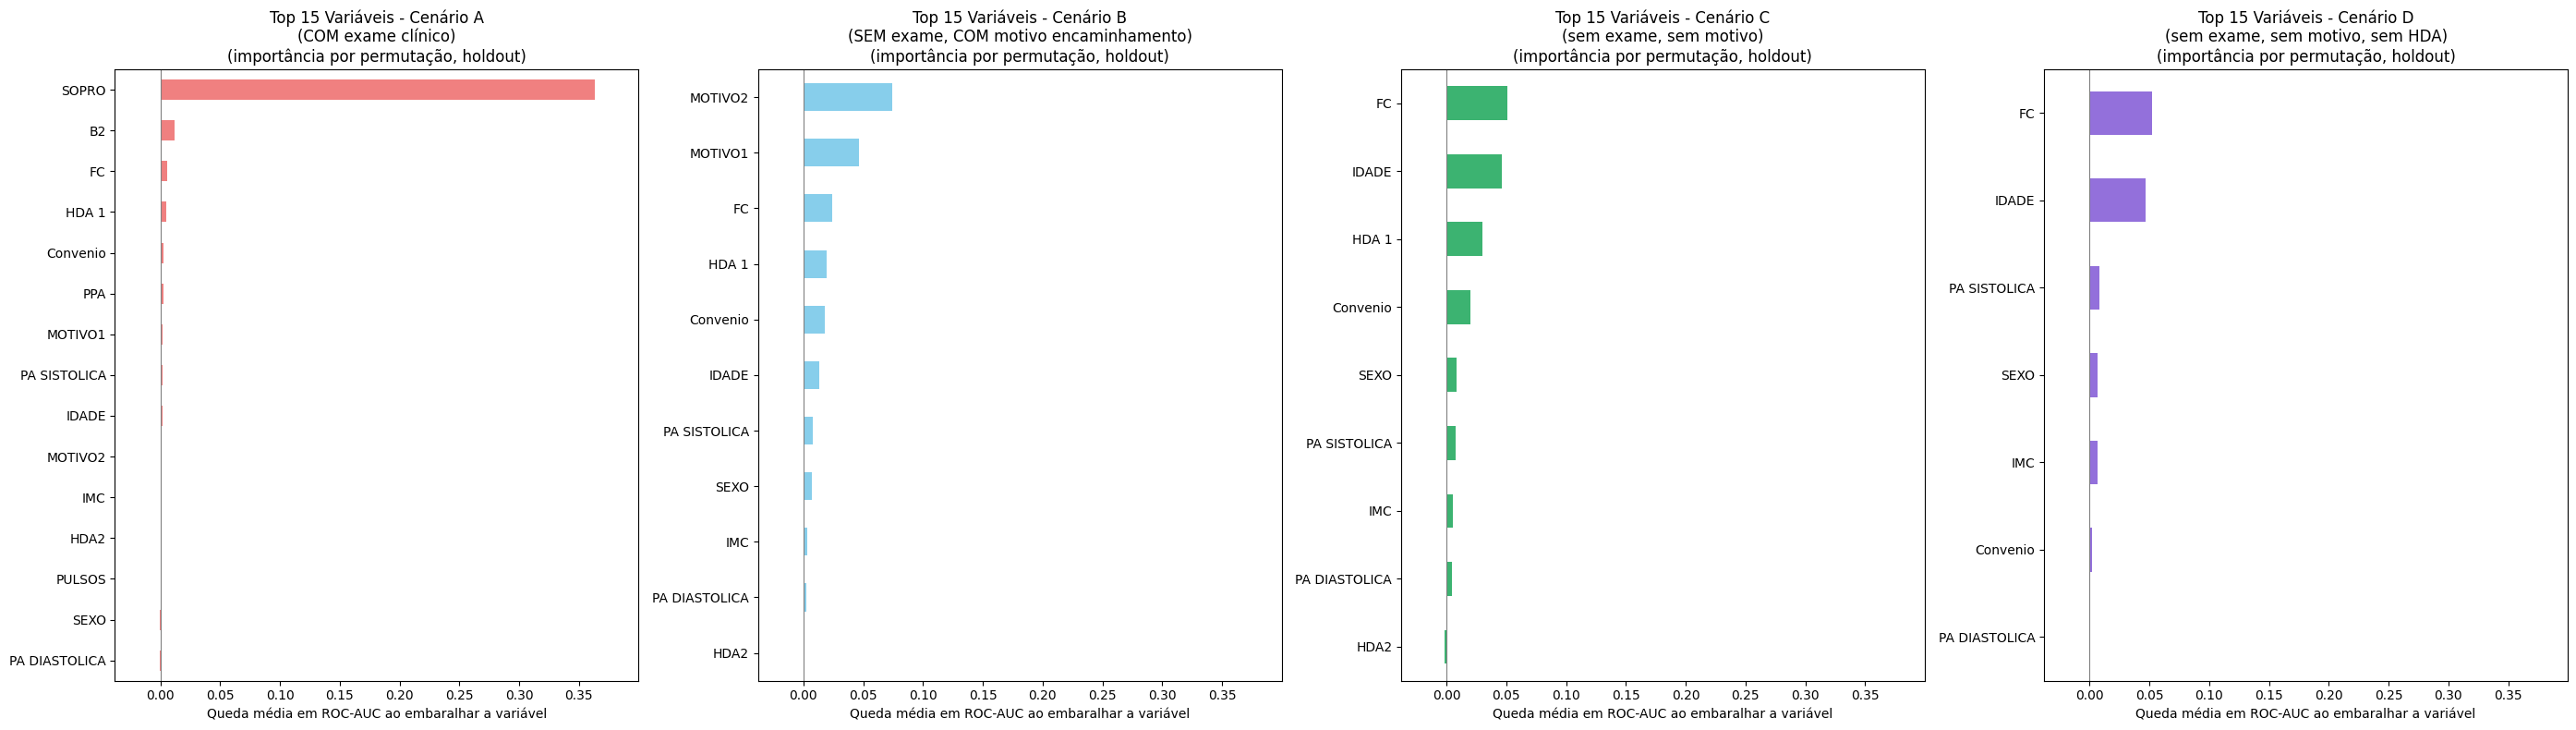


CHECAGEM EXPLORATÓRIA: HOLDOUT TEMPORAL (treino < 2023, holdout = 2023)
Treino: 10843 linha(s) | Holdout temporal: 1 linha(s)
Ano de corte não tem as duas classes (Normal/Anormal) representadas; checagem de holdout temporal pulada.


In [2]:
"""
Pipeline de limpeza e modelagem para triagem de cardiopatia infantil (UCMF).

Compara quatro abordagens via validação cruzada + avaliação final em holdout:
  - Cenário A: modelo COM achados de exame clínico (sopro, pulsos, B2, PPA)
  - Cenário B: modelo SEM esses achados, simulando uma triagem "cega"
                (sem depender de auscultação especializada), mas ainda usando
                o motivo de encaminhamento (MOTIVO1/MOTIVO2) constante na ficha
  - Cenário C: como o B, mas também SEM motivo de encaminhamento — uma
                triagem "verdadeiramente cega", sem a impressão clínica de
                quem encaminhou o paciente (mantém, porém, HDA 1/HDA2 — ver
                Cenário D)
  - Cenário D: como o C, mas também SEM HDA 1/HDA2 (sintomas/queixa já
                categorizados na anamnese, ex: "Dispneia", "Cianose") — a
                versão mais conservadora de "nenhuma impressão clínica
                prévia", incluindo a do próprio serviço que preencheu a ficha

Mudanças de revisões anteriores (mantidas):
  - Peso e Altura removidas do conjunto de variáveis preditoras (ver
    COLS_REMOVER_SEMPRE). Mantém-se o IMC, derivado delas, como resumo.
  - Pipeline numérico padroniza ANTES de imputar (StandardScaler ->
    KNNImputer), para que a distância usada pelo KNNImputer não seja
    dominada por variáveis em escalas maiores (ex: FC, 30-250) sobre
    variáveis em escalas menores (ex: IDADE, IMC).
  - Gradient Boosting recebe sample_weight balanceado manualmente (é o único
    modelo aqui sem class_weight nativo).
  - Holdout (20%, estratificado) separado ANTES da validação cruzada e nunca
    usado na seleção/comparação de modelos.
  - Teste pareado (t de Student) comparando o ROC-AUC dos cenários fold a
    fold, já que todos usam os mesmos splits de CV.
  - Importância de variáveis por permutação (no holdout), não por impureza
    (Gini), para não favorecer artificialmente variáveis contínuas/de alta
    cardinalidade.
  - XGBoost com n_jobs=1 para não competir por threads com o paralelismo do
    cross_validate (n_jobs=-1).
  - PPA: "Não Calculado" é tratado como categoria válida (resultado real de
    que a PA provavelmente não foi medida/calculada), não como ausente. Só
    "#VALUE!" (erro de planilha) é convertido para NaN.
  - Imputação categórica via strategy='constant' com rótulo 'NAO_INFORMADO'
    explícito, em vez de strategy='most_frequent' (que apagava o sinal de
    "não informado/não medido" em colunas com alta proporção de ausência).
  - Categorias raras de Convenio agrupadas em 'OUTRO' aprendendo SOMENTE no
    treino, depois aplicado também ao holdout — sem vazamento de dados.
  - Correção de século das datas usa uma referência fixa vinda do próprio
    dado (data de atendimento da linha) para corrigir a data de nascimento,
    em vez de pd.Timestamp.now() — resultado da limpeza não depende mais de
    QUANDO o script é executado.

Mudanças desta revisão (novas) — encontradas batendo o pipeline contra o
CSV real:
  - Datas em formato serial do Excel (ex: "38574") deixavam de virar NaT
    silenciosamente quando o parse textual dd/mm/yy falhava. Agora
    `parse_data_com_correcao_seculo` tenta, nesses casos, interpretar o
    valor como serial do Excel (origem 1899-12-30) antes de desistir. Isso
    recupera várias centenas de linhas antes descartadas em
    `tratar_datas_e_idade` como "data inválida", quando na verdade só
    estavam num formato diferente.
  - Linhas inteiramente duplicadas (mesmo conteúdo em todas as colunas,
    exceto ID) agora são removidas em `remover_duplicatas`, logo após o
    carregamento e ANTES do split treino/holdout. Sem isso, cópias do mesmo
    registro podiam cair em treino e holdout (ou em folds diferentes da CV)
    simultaneamente, inflando artificialmente ROC-AUC/F1/recall.
  - FC em formato de faixa (ex: "92-100", "170-150") agora é convertido para
    a média da faixa em `parse_valor_com_faixa`, em vez de virar NaN ao
    passar por pd.to_numeric.
  - HDA 1/HDA2 — sintomas/queixa já categorizados na anamnese por outro
    profissional — agora têm tratamento conceitual análogo ao de
    MOTIVO1/MOTIVO2 (ver VARS_SINTOMAS_PREVIOS): entram no novo Cenário D,
    que parte do Cenário C e remove também essas colunas. O Cenário C
    original foi mantido sem essa remoção, para preservar comparabilidade
    com a análise anterior; o Cenário D é a versão mais estrita de
    "nenhuma impressão clínica prévia".
  - IDADE informada e idade calculada por data agora são comparadas em
    `verificar_discrepancia_idade`: uma divergência grande (>5 anos) entre
    as duas é logada como aviso. A função não decide automaticamente qual
    fonte confiar — isso fica para revisão manual — mas a divergência deixa
    de passar batido como antes (hoje `fillna` só age quando IDADE é nula,
    então uma IDADE informada errada nunca era confrontada com a data).
  - Comentário sobre SEXO == "Indeterminado" expandido para deixar
    explícito que `.replace('I', np.nan)` é uma decisão deliberada: essa
    categoria concentra registros de cadastro incompleto (não achado
    clínico de sexo indeterminado/DSD), a julgar pela taxa de ausência
    muito mais alta de NORMAL X ANORMAL e de outras colunas clínicas dentro
    desse subgrupo.
  - Checagem exploratória adicional de holdout temporal (treino nos anos
    mais antigos, holdout no ano de atendimento mais recente) ao final da
    execução principal, em `checagem_holdout_temporal` — o split aleatório
    estratificado usado no resto do script é correto para estimar
    desempenho i.i.d., mas o dataset cobre vários anos e claramente teve
    mudança de protocolo ao longo do tempo (ex: a própria diferenciação de
    PPA "Não Calculado"); essa checagem serve só para sinalizar se o
    desempenho se mantém fora de um split i.i.d., não substitui a análise
    principal.
"""

import logging
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.base import clone
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import roc_auc_score, f1_score, recall_score
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(message)s')
log = logging.getLogger(__name__)


# ==========================================
# CONFIGURAÇÃO
# ==========================================
CSV_PATH = 'UCMF_raw.csv'
TARGET = 'NORMAL X ANORMAL'
RANDOM_STATE = 42
N_SPLITS = 5
N_REPEATS = 1          # aumente (ex: 5) para um teste estatístico mais robusto entre cenários
HOLDOUT_SIZE = 0.2
N_JOBS_CV = 1          # paralelismo do cross_validate (modelos internos usam 1 thread, ver XGBoost)
TOP_N_CONVENIO = 15      # nº de categorias de Convenio mantidas; o resto vira 'OUTRO'
ROTULO_NAO_INFORMADO = 'NAO_INFORMADO'

# Coluna auxiliar interna (ano de atendimento), usada só para a checagem
# exploratória de holdout temporal (ver `checagem_holdout_temporal`). NUNCA
# é uma feature de modelo: `montar_X_y` a descarta automaticamente sempre,
# em todos os cenários, então não precisa entrar em nenhuma lista de
# colunas removidas específica de cenário.
COL_ANO_INTERNO = '_ANO_ATENDIMENTO'

# Achados que dependem de exame físico especializado (auscultação/palpação por
# profissional treinado). PPA é a classificação percentilada derivada de
# PA SISTOLICA/PA DIASTOLICA + idade/sexo, então também entra como "rótulo de
# exame". Os valores brutos de PA SISTOLICA/PA DIASTOLICA/FC permanecem no
# Cenário B porque podem ser medidos em qualquer triagem básica.
VARS_EXAME = ['SOPRO', 'PULSOS', 'B2', 'PPA']

# Motivo de encaminhamento. Embora não seja um "achado de exame" no sentido
# estrito, costuma refletir uma impressão clínica já formada por OUTRO
# profissional (ex: MOTIVO2 = "Sopro" geralmente significa que alguém já
# ouviu um sopro antes de encaminhar o paciente para esta base). Por isso
# entra como variável removida a partir do Cenário C, que busca isolar o
# que dados puramente vitais/demográficos/administrativos conseguem
# prever por si só, sem se apoiar — direta ou indiretamente — em nenhuma
# impressão clínica de quem encaminhou o paciente.
VARS_REFERENCIA = ['MOTIVO1', 'MOTIVO2']

# HDA 1/HDA2: sintomas/queixa já categorizados na anamnese (ex: "Dispneia",
# "Cianose", "Dor precordial"...), refletindo uma triagem prévia — não dado
# vital bruto. Conceitualmente têm o mesmo problema de MOTIVO1/MOTIVO2,
# então entram como variáveis removidas a partir do Cenário D, que isola a
# versão mais estrita de "nenhuma impressão clínica prévia" (nem a de quem
# encaminhou o paciente, nem a do próprio serviço que preencheu a ficha).
# Mantidas no Cenário C (que preserva a definição já usada em revisões
# anteriores) para não quebrar a comparabilidade dos resultados antigos.
VARS_SINTOMAS_PREVIOS = ['HDA 1', 'HDA2']

# Peso e Altura removidas: ~35-45% dos registros trazem 0 como sentinela de
# "não medido" (já tratado como NaN em aplicar_limites_clinicos), o que torna
# essas colunas brutas pouco confiáveis isoladamente. Mantemos o IMC -
# calculado a partir delas antes de descartá-las - como resumo derivado.
COLS_REMOVER_SEMPRE = ['Peso', 'Altura']

MODELO_PARA_IMPORTANCIA = 'Random Forest'


# ==========================================
# 1. FUNÇÕES DE LIMPEZA E ENGENHARIA
# ==========================================
def normalizar_texto_categoria(serie, rotulo_nulo=ROTULO_NAO_INFORMADO):
    """Preenche nulos ANTES de qualquer conversão de texto (evita o clássico
    bug de NaN virar a string literal "nan") e padroniza maiúsculas/espaços.

    Não agrupa categorias raras em 'OUTRO' — isso fica para depois do split
    treino/holdout (ver `ajustar_categorias_raras` / `aplicar_categorias_raras`),
    já que decidir quais categorias são "raras" usando dados do holdout seria
    um vazamento de informação, ainda que pequeno.
    """
    return serie.fillna(rotulo_nulo).str.strip().str.upper()


def ajustar_categorias_raras(serie_treino, top_n=15):
    """Aprende, usando SOMENTE o conjunto de treino, quais categorias são
    frequentes o bastante para manter sua própria coluna dummy. Retorna o
    índice de categorias a manter; o restante vira 'OUTRO' em
    `aplicar_categorias_raras`. Mantém o resultado fora do one-hot encoding
    cego a centenas de variantes de digitação (ex: 'Camed' / 'CAMED'), que
    além de caras computacionalmente inflam artificialmente a importância de
    variáveis no Random Forest (a importância de Gini favorece variáveis de
    alta cardinalidade)."""
    return serie_treino.value_counts().nlargest(top_n).index


def aplicar_categorias_raras(serie, categorias_mantidas, rotulo_outro='OUTRO'):
    """Aplica o conjunto de categorias aprendido em `ajustar_categorias_raras`
    a uma série (treino OU holdout) — garante que treino e holdout usem
    exatamente a mesma definição de 'OUTRO'."""
    return serie.where(serie.isin(categorias_mantidas), rotulo_outro)


def remover_duplicatas(df, exceto=('ID',)):
    """Remove linhas inteiramente duplicadas (mesmo conteúdo em todas as
    colunas, exceto as listadas em `exceto`).

    A base real tem centenas de linhas com mesmo DN, Atendimento, sexo,
    todos os achados clínicos e o mesmo NORMAL X ANORMAL — só o ID muda.
    Isso tem cara de duplicação de entrada de dados, não de duas consultas
    reais coincidentes em tudo. Sem essa remoção, o train_test_split
    aleatório pode colocar cópias do mesmo registro em treino e holdout (ou
    em folds diferentes da CV) ao mesmo tempo, inflando artificialmente
    ROC-AUC/F1/recall: o modelo estaria sendo "testado" em algo que viu
    (quase) literalmente no treino.

    Chamado logo após `carregar_e_limpar_dados`, antes de qualquer outra
    transformação — assim a comparação usa todas as colunas originais, não
    só as que sobrevivem depois de `tratar_datas_e_idade`/
    `aplicar_limites_clinicos` descartarem algumas.
    """
    cols_dedup = [c for c in df.columns if c not in exceto]
    n_antes = len(df)
    df = df.drop_duplicates(subset=cols_dedup).copy()
    n_removidas = n_antes - len(df)
    if n_removidas:
        log.warning(f"Removidas {n_removidas} linha(s) duplicada(s) "
                    f"(idênticas exceto {', '.join(exceto)}).")
    return df


def carregar_e_limpar_dados(filepath):
    df = pd.read_csv(filepath)

    # Importante: NÃO usamos .astype(str) em colunas inteiras. Fazer isso
    # pode transformar valores ausentes reais na string literal "nan", que
    # depois escapa de qualquer tratamento de nulo. O acessor .str já
    # propaga NaN corretamente sem precisar dessa conversão.
    colunas_texto = df.select_dtypes(include=['object']).columns
    for col in colunas_texto:
        df[col] = df[col].str.strip()

    # Conferido contra value_counts() reais da base: as únicas duplicatas de
    # grafia existentes em NORMAL X ANORMAL ('anormal', 'Normais'), SOPRO
    # ('sistólico'/'Sistólico', 'contínuo'/'Contínuo') e PULSOS
    # ('NORMAIS'/'Normais', 'AMPLOS'/'Amplos') já são unificadas pelo código
    # abaixo. Atenção: nos value_counts() mais recentes da base essas
    # variantes em minúsculo/caixa alta específicas não aparecem mais — as
    # linhas abaixo são mantidas de forma defensiva (são idempotentes, não
    # fazem mal se não houver match), mas vale reconferir contra o CSV bruto
    # se a fonte de dados mudar.
    df['NORMAL X ANORMAL'] = df['NORMAL X ANORMAL'].str.title().replace('Normais', 'Normal')

    # SEXO == "Indeterminado" -> NaN é uma decisão deliberada, não um
    # acaso de implementação: olhando a base bruta, quando SEXO é
    # "Indeterminado" o próprio NORMAL X ANORMAL já está ausente numa
    # fração bem maior dos casos do que nas demais categorias de sexo, e o
    # mesmo padrão se repete nas outras colunas clínicas. Isso é mais
    # coerente com "registro de cadastro incompleto" do que com prevalência
    # real de sexo indeterminado/DSD (que seria uma fração bem menor da
    # base). Por isso tratamos como ausente em vez de como uma terceira
    # categoria válida de SEXO.
    df['SEXO'] = df['SEXO'].str.upper().str[0].replace('I', np.nan)

    df['SOPRO'] = df['SOPRO'].replace({'sistólico': 'Sistólico', 'contínuo': 'Contínuo'})
    df['PULSOS'] = df['PULSOS'].replace({'NORMAIS': 'Normais', 'AMPLOS': 'Amplos'})

    # "Não Calculado" passa a ser tratado como categoria válida, não como
    # ausente: é um resultado real (a PA provavelmente não foi medida/
    # calculada nessa consulta) e carrega informação própria. Tratá-lo como
    # NaN e depois imputar por moda inflava artificialmente a categoria
    # "Normal" (a mais comum entre os valores realmente calculados). Só
    # "#VALUE!" (erro de planilha, não um resultado clínico) vira NaN.
    df['PPA'] = df['PPA'].replace('#VALUE!', np.nan)

    # Limpeza básica de Convenio (nulos explícitos + padronização de texto).
    # O agrupamento de categorias raras em 'OUTRO' é feito depois do split
    # treino/holdout, em main, para não vazar informação do holdout.
    df['Convenio'] = normalizar_texto_categoria(df['Convenio'])

    return df


def parse_valor_com_faixa(serie):
    """Converte valores no formato 'min-max' (ex: '92-100', '170-150') para
    a média da faixa, em vez de deixá-los virar NaN num pd.to_numeric
    direto. Cobre algumas linhas de FC registradas como intervalo em vez de
    valor único — mas é genérica, podendo ser reaproveitada em qualquer
    outra coluna numérica que apresente o mesmo padrão.

    Valores já numéricos (ou realmente ausentes) passam direto pelo
    pd.to_numeric normal; só o que falha nessa primeira tentativa E casa
    com o padrão 'número-número' é recalculado como média da faixa. Um
    valor ausente de fato (NaN) continua NaN: a string "nan" resultante de
    `.astype(str)` não casa com o padrão de faixa, então não é inventado
    nenhum valor onde não havia dado.
    """
    serie_str = serie.astype(str)
    extraido = serie_str.str.extract(r'^\s*(\d+(?:\.\d+)?)\s*-\s*(\d+(?:\.\d+)?)\s*$')
    media_faixa = extraido.astype(float).mean(axis=1)

    valor_numerico = pd.to_numeric(serie, errors='coerce')
    return valor_numerico.fillna(media_faixa)


def verificar_discrepancia_idade(idade_informada, idade_calc, limite_anos=5):
    """Loga (sem decidir automaticamente) os casos em que a IDADE informada
    na ficha e a idade calculada a partir das datas (Atendimento - DN)
    divergem mais do que `limite_anos`.

    Hoje `IDADE.fillna(idade_calc)` só atua quando IDADE é nula — então uma
    IDADE informada incorreta (erro de digitação na própria IDADE, ou em DN
    sem ter disparado a correção de século) nunca é confrontada com a data.
    Decidir qual fonte confiar caso a caso exige revisão humana; esta
    função só sinaliza a divergência, sem alterar nenhum valor.
    """
    ambos_presentes = idade_informada.notna() & idade_calc.notna()
    diferenca = (idade_informada - idade_calc).abs()
    discrepantes = ambos_presentes & (diferenca > limite_anos)

    n = discrepantes.sum()
    if n:
        pior = diferenca[discrepantes].max()
        log.warning(
            f"IDADE informada e idade calculada por data divergem em mais "
            f"de {limite_anos} anos em {n} linha(s) (diferença máxima: "
            f"{pior:.1f} anos). IDADE informada foi mantida sem alteração "
            f"em todas elas; revisão manual recomendada para decidir qual "
            f"fonte confiar caso a caso."
        )
    return discrepantes


def tratar_datas_e_idade(df):
    def parse_data_com_correcao_seculo(serie, referencia):
        """Corrige datas com ano de 2 dígitos interpretado no século errado
        (ex: "27" virando 2027 em vez de 1927). `referencia` é o ponto de
        corte: qualquer data parseada que caia DEPOIS dela é considerada erro
        de século e recua 100 anos. Importante: `referencia` deve ser algo
        determinado pelo próprio dado (não pd.Timestamp.now()) sempre que
        possível, para que o resultado da limpeza não dependa de QUANDO o
        script é executado."""
        datas = pd.to_datetime(serie, format='%d/%m/%y', errors='coerce')

        # Algumas linhas vêm como número serial do Excel (ex: "38574"),
        # resultado de células do CSV original formatadas como número em
        # vez de texto/data. O parse textual acima não reconhece esse
        # padrão e devolve NaT silenciosamente — sem o fallback abaixo,
        # essas linhas eram descartadas mais adiante (ver
        # `linhas_invalidas`) como "data inválida", mesmo tendo uma data
        # perfeitamente recuperável (origem do sistema de datas do Excel:
        # 1899-12-30, padrão 1900 usado pelo Windows).
        candidato_serial = pd.to_numeric(serie, errors='coerce')
        precisa_fallback = datas.isna() & candidato_serial.notna()
        if precisa_fallback.any():
            datas_serial = pd.to_datetime(
                candidato_serial[precisa_fallback], unit='D',
                origin='1899-12-30', errors='coerce'
            )
            datas.loc[precisa_fallback] = datas_serial

        futuras = datas > referencia
        datas.loc[futuras] = datas.loc[futuras] - pd.DateOffset(years=100)
        return datas

    # Atendimento: comparar com "agora" aqui é razoável e estável — uma data
    # de atendimento já registrada no passado não passa a ser "futura" de
    # novo conforme o tempo passa (diferente de comparar a DATA DE
    # NASCIMENTO com "agora", que é o que causava o bug de reprodutibilidade).
    atend = parse_data_com_correcao_seculo(df['Atendimento'], pd.Timestamp.now())

    # DN agora é comparado com a própria data de atendimento da linha — uma
    # referência fixa, vinda do dado, em vez de pd.Timestamp.now(). Ninguém
    # nasce depois da própria consulta, então esse critério é tão correto
    # quanto comparar com "hoje" para detectar erro de século, mas sem
    # depender do momento de execução do script.
    dn = parse_data_com_correcao_seculo(df['DN'], atend)

    linhas_invalidas = df['IDADE'].isna() & (dn.isna() | atend.isna())
    df = df[~linhas_invalidas].copy()
    dn = dn[~linhas_invalidas]
    atend = atend[~linhas_invalidas]

    idade_calc = (atend - dn).dt.days / 365.25

    # Sinaliza (sem decidir automaticamente) divergência grande entre a
    # IDADE informada na ficha e a calculada pelas datas — ver
    # `verificar_discrepancia_idade`. Roda ANTES do fillna, já que depois
    # dele toda linha com IDADE informada continuaria com esse valor,
    # mascarando a divergência.
    verificar_discrepancia_idade(df['IDADE'], idade_calc)

    df['IDADE'] = df['IDADE'].fillna(idade_calc).round(2)

    # Guarda o ano de atendimento ANTES de descartar a coluna Atendimento —
    # não como feature de modelo (ver `montar_X_y`, que descarta
    # COL_ANO_INTERNO automaticamente, sempre, em todos os cenários), só
    # para permitir mais adiante uma checagem exploratória de holdout
    # temporal (`checagem_holdout_temporal`).
    df[COL_ANO_INTERNO] = atend.dt.year

    return df.drop(columns=['Atendimento', 'DN', 'ID'], errors='ignore')


def aplicar_limites_clinicos(df):
    df.loc[(df['IDADE'] < 0) | (df['IDADE'] > 19), 'IDADE'] = np.nan
    df.loc[df['Peso'] <= 0, 'Peso'] = np.nan
    df.loc[df['Altura'] <= 0, 'Altura'] = np.nan

    df['PA SISTOLICA'] = pd.to_numeric(df['PA SISTOLICA'], errors='coerce')
    df.loc[(df['PA SISTOLICA'] <= 0) | (df['PA SISTOLICA'] > 300), 'PA SISTOLICA'] = np.nan

    df['PA DIASTOLICA'] = pd.to_numeric(df['PA DIASTOLICA'], errors='coerce')
    df.loc[(df['PA DIASTOLICA'] <= 0) | (df['PA DIASTOLICA'] > 200), 'PA DIASTOLICA'] = np.nan

    # Algumas linhas de FC vêm como faixa (ex: "92-100", "170-150") em vez
    # de valor único; `parse_valor_com_faixa` converte para a média da
    # faixa em vez de deixar pd.to_numeric descartar essas linhas como NaN.
    df['FC'] = parse_valor_com_faixa(df['FC'])
    df.loc[(df['FC'] < 30) | (df['FC'] > 250), 'FC'] = np.nan

    # Recalcula o IMC a partir do Peso/Altura já limpos em vez de confiar no
    # valor original do CSV.
    altura_m = df['Altura'] / 100
    df['IMC'] = np.where(altura_m > 0, df['Peso'] / (altura_m ** 2), np.nan)
    df.loc[(df['IMC'] < 5) | (df['IMC'] > 45), 'IMC'] = np.nan

    # Peso e Altura saem do conjunto de variáveis (ver COLS_REMOVER_SEMPRE no
    # topo do arquivo); o IMC, já calculado acima, permanece como resumo.
    return df.drop(columns=COLS_REMOVER_SEMPRE, errors='ignore')


# ==========================================
# 2. FUNÇÕES DE MODELAGEM
# ==========================================
def montar_X_y(df, drop_cols=None, target=TARGET):
    # COL_ANO_INTERNO é descartada SEMPRE, em todos os cenários — é só uma
    # coluna auxiliar para a checagem de holdout temporal, nunca uma
    # feature de modelo (ver definição da constante).
    cols_excluir = list(drop_cols or []) + [COL_ANO_INTERNO]
    df = df.drop(columns=cols_excluir, errors='ignore')
    y = df[target]
    X = df.drop(columns=[target])
    return X, y


def inferir_tipos_coluna(X):
    num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    # Garante que nenhuma coluna está sendo descartada silenciosamente pelo
    # ColumnTransformer (remainder='drop' por padrão) por causa de um dtype
    # não mapeado em num_cols/cat_cols.
    faltantes = set(X.columns) - set(num_cols) - set(cat_cols)
    assert not faltantes, (
        f"Colunas com dtype não tratado seriam descartadas silenciosamente: {faltantes}"
    )
    return num_cols, cat_cols


def construir_pipeline(num_cols, cat_cols, modelo):
    # Padronizamos ANTES de imputar: o StandardScaler do sklearn ignora NaN
    # ao calcular média/desvio e os mantém no transform, então o KNNImputer
    # passa a calcular distância já no espaço padronizado — evita que
    # variáveis em escala maior (ex: FC) dominem a escolha de vizinhos sobre
    # variáveis em escala menor (ex: IMC, IDADE). Isso não afeta o ajuste de
    # modelos baseados em árvore, então o mesmo pipeline serve para todos.
    numeric_transformer = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('knn', KNNImputer(n_neighbors=5)),
    ])

    categorical_transformer = Pipeline(steps=[
        # Trocado de strategy='most_frequent' para um rótulo constante
        # explícito. Várias colunas categóricas têm proporção alta de
        # ausência (ex: HDA2 ~97%, e parcelas relevantes em B2, SOPRO,
        # PULSOS, PPA) — "most_frequent" simplesmente absorvia essas linhas
        # dentro da categoria mais comum, apagando o sinal de "isso não foi
        # informado/medido", que em dado clínico raramente é aleatório.
        ('imputer', SimpleImputer(strategy='constant', fill_value=ROTULO_NAO_INFORMADO)),
        ('ohe', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, num_cols),
            ('cat', categorical_transformer, cat_cols)
        ])

    return Pipeline(steps=[('preprocessor', preprocessor), ('classifier', modelo)])


def _cross_validate_compat(pipeline, X, y, cv, scoring, sample_weight=None, n_jobs=N_JOBS_CV):
    """Wrapper para cross_validate que roteia sample_weight ao classificador
    final do pipeline (ex: Gradient Boosting). Tenta a API atual (params=) e
    cai para fit_params= em versões mais antigas do scikit-learn."""
    fit_kwargs = {'classifier__sample_weight': sample_weight} if sample_weight is not None else None
    try:
        return cross_validate(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=n_jobs, params=fit_kwargs)
    except TypeError:
        return cross_validate(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=n_jobs, fit_params=fit_kwargs)


def avaliar_modelos_cv(X, y, num_cols, cat_cols):
    sample_weight_balanceado = compute_sample_weight('balanced', y)
    scale_pos_weight = (y == 0).sum() / max((y == 1).sum(), 1)

    modelos = {
        "Regressão Logística": LogisticRegression(
            max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'),
        "SVC": SVC(
            kernel='rbf', random_state=RANDOM_STATE, class_weight='balanced'),
        "Random Forest": RandomForestClassifier(
            n_estimators=100, random_state=RANDOM_STATE, class_weight='balanced'),
        # GradientBoostingClassifier não tem class_weight nativo (diferente
        # dos demais modelos do sklearn aqui); por isso recebe sample_weight
        # balanceado manualmente via _cross_validate_compat mais abaixo.
        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=100, random_state=RANDOM_STATE),
        "XGBoost": XGBClassifier(
            n_estimators=100, random_state=RANDOM_STATE, eval_metric='logloss',
            scale_pos_weight=scale_pos_weight, n_jobs=1),  # n_jobs=1: evita threads
            # internas do XGBoost disputando CPU com o paralelismo do cross_validate
    }

    cv = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=RANDOM_STATE)
    resultados = {}

    log.info(f"{'Modelo':<22} | {'ROC-AUC':<16} | {'F1-Score':<16} | {'Recall (Anormal)'}")
    log.info("-" * 78)

    for nome, modelo in modelos.items():
        pipeline = construir_pipeline(num_cols, cat_cols, modelo)
        sw = sample_weight_balanceado if nome == "Gradient Boosting" else None
        scores = _cross_validate_compat(
            pipeline, X, y, cv=cv, scoring=['roc_auc', 'f1', 'recall'], sample_weight=sw
        )

        roc_auc, roc_std = scores['test_roc_auc'].mean(), scores['test_roc_auc'].std()
        f1, f1_std = scores['test_f1'].mean(), scores['test_f1'].std()
        recall, recall_std = scores['test_recall'].mean(), scores['test_recall'].std()

        # IMPORTANTE: este 'pipeline' NÃO foi treinado aqui. cross_validate()
        # clona o estimador internamente para cada fold e descarta os clones
        # ao final. O fit() real acontece em avaliar_holdout(), que é quem
        # efetivamente precisa do modelo treinado.
        resultados[nome] = {
            'pipeline': pipeline,
            'sample_weight': sw,
            'roc_auc': scores['test_roc_auc'],
            'f1': scores['test_f1'],
            'recall': scores['test_recall'],
        }

        log.info(f"{nome:<22} | {roc_auc:.4f} +/- {roc_std:.4f} | "
                 f"{f1:.4f} +/- {f1_std:.4f} | {recall:.4f} +/- {recall_std:.4f}")

    return resultados


def comparar_cenarios(resultados_por_cenario):
    """Teste pareado (t de Student) no ROC-AUC fold a fold entre TODOS os
    pares de cenários fornecidos. Válido porque todos os cenários usam o
    mesmo y (mesmas linhas, mesmo target), logo o RepeatedStratifiedKFold com
    o mesmo random_state produz exatamente os mesmos splits em todos eles.

    `resultados_por_cenario` é um dict {label_do_cenario: resultados}, onde
    `resultados` é o dict retornado por `avaliar_modelos_cv` (uma entrada por
    modelo, com a chave 'roc_auc' contendo os scores fold a fold).

    Aviso: com poucos folds (N_SPLITS x N_REPEATS) esse teste tem baixo poder
    estatístico — um p-valor não significativo pode simplesmente refletir
    poucas observações, não ausência de diferença real. Aumente N_REPEATS
    para um teste mais robusto.
    """
    from itertools import combinations

    labels = list(resultados_por_cenario.keys())
    nomes_modelos = list(next(iter(resultados_por_cenario.values())).keys())

    for label_a, label_b in combinations(labels, 2):
        log.info("\n" + "=" * 78)
        log.info(f"COMPARAÇÃO ESTATÍSTICA: {label_a}  vs.  {label_b}  (ROC-AUC, teste t pareado)")
        log.info("=" * 78)
        log.info(f"{'Modelo':<22} | {'AUC ' + label_a[:14]:<19} | {'AUC ' + label_b[:14]:<19} | {'Δ':<8} | p-valor")
        log.info("-" * 88)
        for nome in nomes_modelos:
            a = resultados_por_cenario[label_a][nome]['roc_auc']
            b = resultados_por_cenario[label_b][nome]['roc_auc']
            _, p = stats.ttest_rel(a, b)
            log.info(f"{nome:<22} | {a.mean():.4f}{'':<13} | {b.mean():.4f}{'':<13} | "
                     f"{a.mean() - b.mean():+.4f} | {p:.4f}")


def avaliar_holdout(nome_modelo, pipeline, X_train, y_train, X_hold, y_hold, label_cenario, sample_weight=None):
    """Treina o pipeline (já configurado, ainda não ajustado) no conjunto de
    treino e avalia no holdout — dados nunca vistos durante a validação
    cruzada de seleção de modelo. Retorna o pipeline já ajustado, para reuso
    na extração de importâncias por permutação."""
    pipeline = clone(pipeline)
    fit_kwargs = {'classifier__sample_weight': sample_weight} if sample_weight is not None else {}
    pipeline.fit(X_train, y_train, **fit_kwargs)

    if hasattr(pipeline, 'predict_proba'):
        proba = pipeline.predict_proba(X_hold)[:, 1]
    else:
        proba = pipeline.decision_function(X_hold)
    pred = pipeline.predict(X_hold)

    auc = roc_auc_score(y_hold, proba)
    f1 = f1_score(y_hold, pred)
    recall = recall_score(y_hold, pred)
    log.info(f"[Holdout | {label_cenario}] {nome_modelo}: "
             f"ROC-AUC={auc:.4f}  F1={f1:.4f}  Recall(Anormal)={recall:.4f}")
    return pipeline


def extrair_importancias(pipeline_ajustado, X_hold, y_hold, scoring='roc_auc', n_repeats=10):
    """Importância por permutação no holdout, sobre as colunas ORIGINAIS de
    entrada (a permutação embaralha colunas de X antes do ColumnTransformer,
    então o resultado já vem com os nomes reais das variáveis — sem precisar
    reconstruir nomes de dummies do one-hot, como seria necessário com
    feature_importances_)."""
    r = permutation_importance(
        pipeline_ajustado, X_hold, y_hold, scoring=scoring,
        n_repeats=n_repeats, random_state=RANDOM_STATE, n_jobs=N_JOBS_CV
    )
    importancias = pd.Series(r.importances_mean, index=X_hold.columns)
    return importancias.sort_values(ascending=True).tail(15)


def rodar_cenario(label, df_train_raw, df_holdout_raw, drop_cols):
    log.info("\n" + "=" * 78)
    log.info(label)
    log.info("=" * 78)

    X_train, y_train = montar_X_y(df_train_raw, drop_cols=drop_cols)
    num_cols, cat_cols = inferir_tipos_coluna(X_train)
    resultados = avaliar_modelos_cv(X_train, y_train, num_cols, cat_cols)

    X_hold, y_hold = montar_X_y(df_holdout_raw, drop_cols=drop_cols)
    info_modelo = resultados[MODELO_PARA_IMPORTANCIA]
    pipeline_ajustado = avaliar_holdout(
        MODELO_PARA_IMPORTANCIA, info_modelo['pipeline'], X_train, y_train,
        X_hold, y_hold, label, sample_weight=info_modelo['sample_weight']
    )
    importancias = extrair_importancias(pipeline_ajustado, X_hold, y_hold)

    return resultados, importancias


def checagem_holdout_temporal(df_base, drop_cols):
    """Checagem exploratória ADICIONAL (fora da comparação A/B/C/D
    principal): treina num corte temporal — todos os anos de atendimento
    exceto o mais recente — e avalia no ano mais recente, em vez do split
    aleatório estratificado usado no resto do script.

    O split aleatório é correto para estimar desempenho i.i.d., mas o
    dataset cobre vários anos e claramente teve mudança de protocolo ao
    longo do tempo (ex: a própria diferenciação de PPA "Não Calculado").
    Esta função só sinaliza se o desempenho se mantém fora de um split
    i.i.d.; não substitui nem altera a análise principal, e não participa
    da seleção/comparação de modelos.

    Usa o conjunto de variáveis do Cenário C (sem exame clínico, sem motivo
    de encaminhamento) como representativo do caso de uso real mencionado
    na revisão — "triar pacientes novos a partir de agora" — e Random
    Forest (mesmo modelo usado para importâncias em `rodar_cenario`) por
    simplicidade. Linhas sem ano de atendimento conhecido são descartadas
    só para esta checagem.
    """
    if COL_ANO_INTERNO not in df_base.columns:
        log.warning("Coluna de ano de atendimento ausente; checagem de holdout temporal pulada.")
        return

    df_ano = df_base.dropna(subset=[COL_ANO_INTERNO]).copy()
    df_ano[COL_ANO_INTERNO] = df_ano[COL_ANO_INTERNO].astype(int)
    anos = sorted(df_ano[COL_ANO_INTERNO].unique())
    if len(anos) < 2:
        log.warning("Menos de 2 anos distintos de atendimento; checagem de holdout temporal pulada.")
        return

    ano_corte = anos[-1]
    df_treino_temp = df_ano[df_ano[COL_ANO_INTERNO] < ano_corte].copy()
    df_hold_temp = df_ano[df_ano[COL_ANO_INTERNO] == ano_corte].copy()

    log.info("\n" + "=" * 78)
    log.info(f"CHECAGEM EXPLORATÓRIA: HOLDOUT TEMPORAL (treino < {ano_corte}, "
             f"holdout = {ano_corte})")
    log.info("=" * 78)
    log.info(f"Treino: {len(df_treino_temp)} linha(s) | Holdout temporal: {len(df_hold_temp)} linha(s)")

    if df_treino_temp[TARGET].nunique() < 2 or df_hold_temp[TARGET].nunique() < 2:
        log.warning("Ano de corte não tem as duas classes (Normal/Anormal) "
                    "representadas; checagem de holdout temporal pulada.")
        return

    # Mesmo tratamento de categorias raras de Convenio do fluxo principal —
    # aprendido SOMENTE no recorte de treino temporal, aplicado ao holdout
    # temporal, para não vazar informação do "futuro" para o passado.
    categorias_convenio_temp = ajustar_categorias_raras(df_treino_temp['Convenio'], top_n=TOP_N_CONVENIO)
    df_treino_temp['Convenio'] = aplicar_categorias_raras(df_treino_temp['Convenio'], categorias_convenio_temp)
    df_hold_temp['Convenio'] = aplicar_categorias_raras(df_hold_temp['Convenio'], categorias_convenio_temp)

    X_train, y_train = montar_X_y(df_treino_temp, drop_cols=drop_cols)
    X_hold, y_hold = montar_X_y(df_hold_temp, drop_cols=drop_cols)
    num_cols, cat_cols = inferir_tipos_coluna(X_train)

    modelo = RandomForestClassifier(
        n_estimators=100, random_state=RANDOM_STATE, class_weight='balanced')
    pipeline = construir_pipeline(num_cols, cat_cols, modelo)
    pipeline.fit(X_train, y_train)

    proba = pipeline.predict_proba(X_hold)[:, 1]
    pred = pipeline.predict(X_hold)
    auc = roc_auc_score(y_hold, proba)
    f1 = f1_score(y_hold, pred)
    recall = recall_score(y_hold, pred)

    log.info(f"[Holdout temporal | Cenário C, Random Forest] "
             f"ROC-AUC={auc:.4f}  F1={f1:.4f}  Recall(Anormal)={recall:.4f}")
    log.info("Compare com o ROC-AUC do Cenário C no holdout aleatório (acima); "
             "uma queda grande aqui sugere drift de protocolo/composição ao "
             "longo do tempo que o split i.i.d. não captura. Repita com outros "
             "conjuntos de drop_cols (ex: Cenário D) se quiser checar os demais.")


# ==========================================
# 3. EXECUÇÃO PRINCIPAL (TESTE A/B/C/D)
# ==========================================
if __name__ == "__main__":
    log.info("--- Carregando e Processando Dados ---")
    df_base = carregar_e_limpar_dados(CSV_PATH)

    # Deduplicação ANTES de qualquer outra transformação, usando todas as
    # colunas originais (exceto ID) — ver docstring de `remover_duplicatas`.
    df_base = remover_duplicatas(df_base)

    df_base = tratar_datas_e_idade(df_base)
    df_base = aplicar_limites_clinicos(df_base)  # já remove Peso/Altura

    df_base = df_base.dropna(subset=[TARGET]).copy()
    df_base[TARGET] = df_base[TARGET].map({'Normal': 0, 'Anormal': 1})
    alvo_invalido = df_base[TARGET].isna()
    if alvo_invalido.any():
        log.warning(f"Aviso: {alvo_invalido.sum()} linhas descartadas por valor "
                    f"inesperado em '{TARGET}'.")
        df_base = df_base[~alvo_invalido]

    # Holdout separado ANTES de qualquer CV/seleção de modelo — fica de fora
    # de todo o processo de comparação e tuning, para uma estimativa final
    # não otimista.
    df_train_raw, df_holdout_raw = train_test_split(
        df_base, test_size=HOLDOUT_SIZE, stratify=df_base[TARGET], random_state=RANDOM_STATE
    )
    df_train_raw = df_train_raw.copy()
    df_holdout_raw = df_holdout_raw.copy()

    # Agrupamento de categorias raras de Convenio em 'OUTRO': aprendido
    # SOMENTE no treino e aplicado a ambos (ver docstring do módulo —
    # corrige vazamento de dados presente em versão anterior, que decidia
    # isso sobre a base inteira antes do split).
    categorias_convenio = ajustar_categorias_raras(df_train_raw['Convenio'], top_n=TOP_N_CONVENIO)
    df_train_raw['Convenio'] = aplicar_categorias_raras(df_train_raw['Convenio'], categorias_convenio)
    df_holdout_raw['Convenio'] = aplicar_categorias_raras(df_holdout_raw['Convenio'], categorias_convenio)

    vars_exame_presentes = [c for c in VARS_EXAME if c in df_base.columns]
    vars_referencia_presentes = [c for c in VARS_REFERENCIA if c in df_base.columns]
    vars_sintomas_previos_presentes = [c for c in VARS_SINTOMAS_PREVIOS if c in df_base.columns]

    resultados_A, importancias_A = rodar_cenario(
        "CENÁRIO A: Modelo COM Variáveis de Exame Clínico",
        df_train_raw, df_holdout_raw, drop_cols=None
    )
    resultados_B, importancias_B = rodar_cenario(
        "CENÁRIO B: Modelo SEM Exame Clínico (mantém motivo de encaminhamento)",
        df_train_raw, df_holdout_raw, drop_cols=vars_exame_presentes
    )
    resultados_C, importancias_C = rodar_cenario(
        "CENÁRIO C: Triagem Verdadeiramente Cega (sem exame E sem motivo de encaminhamento)",
        df_train_raw, df_holdout_raw, drop_cols=vars_exame_presentes + vars_referencia_presentes
    )
    resultados_D, importancias_D = rodar_cenario(
        "CENÁRIO D: Triagem Cega + Sem HDA (sem exame, sem motivo de "
        "encaminhamento E sem HDA1/HDA2 — nenhuma impressão clínica prévia, "
        "nem a de quem encaminhou nem a do próprio serviço)",
        df_train_raw, df_holdout_raw,
        drop_cols=vars_exame_presentes + vars_referencia_presentes + vars_sintomas_previos_presentes
    )

    comparar_cenarios({
        'Cenário A': resultados_A,
        'Cenário B': resultados_B,
        'Cenário C': resultados_C,
        'Cenário D': resultados_D,
    })

    # ==========================================
    # 4. COMPARAÇÃO VISUAL DAS VARIÁVEIS
    # ==========================================
    log.info("\n--- Gerando Gráficos de Comparação ---")
    fig, axes = plt.subplots(1, 4, figsize=(28, 8))

    painéis = [
        (importancias_A, 'lightcoral', 'Top 15 Variáveis - Cenário A\n(COM exame clínico)'),
        (importancias_B, 'skyblue', 'Top 15 Variáveis - Cenário B\n(SEM exame, COM motivo encaminhamento)'),
        (importancias_C, 'mediumseagreen', 'Top 15 Variáveis - Cenário C\n(sem exame, sem motivo)'),
        (importancias_D, 'mediumpurple', 'Top 15 Variáveis - Cenário D\n(sem exame, sem motivo, sem HDA)'),
    ]

    # Importância por permutação pode ficar levemente negativa (ruído de
    # amostragem em variáveis sem sinal real) — o eixo X precisa acomodar
    # isso, não pode simplesmente começar em 0. Mesma escala em todos os
    # painéis para permitir comparar a magnitude da importância entre eles.
    todas_importancias = pd.concat([p[0] for p in painéis])
    valor_min = min(0, todas_importancias.min())
    valor_max = todas_importancias.max()
    margem = (valor_max - valor_min) * 0.1
    limite_inf, limite_sup = valor_min - margem, valor_max + margem

    for ax, (importancias, cor, titulo) in zip(axes, painéis):
        importancias.plot(kind='barh', color=cor, ax=ax)
        ax.set_title(titulo + '\n(importância por permutação, holdout)')
        ax.set_xlabel('Queda média em ROC-AUC ao embaralhar a variável')
        ax.set_xlim(limite_inf, limite_sup)
        ax.axvline(0, color='gray', linewidth=0.8)

    plt.tight_layout()
    plt.savefig('comparacao_importancias.png', dpi=150, bbox_inches='tight')
    log.info("Gráfico salvo em comparacao_importancias.png")
    plt.show()

    # ==========================================
    # 5. CHECAGEM EXPLORATÓRIA ADICIONAL: HOLDOUT TEMPORAL
    # ==========================================
    checagem_holdout_temporal(
        df_base, drop_cols=vars_exame_presentes + vars_referencia_presentes
    )